## Deteccion de regimenes de mercado

### Veo empresas argentinas


In [ ]:
import yfinance as yf
import pandas as pd

tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']

start = '2008-01-01'
end = '2025-01-01'

raw = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False
)

data = raw['Close']
aperturas = raw['Open']
volumen = raw['Volume']

[*********************100%***********************]  8 of 8 completed


In [112]:
ticker = 'GGAL'
open_ticker = aperturas[ticker].copy()
close_ticker = data[ticker].copy()

open_ticker.index = open_ticker.index.tz_localize(None)
close_ticker.index = close_ticker.index.tz_localize(None)

gap_overnight = open_ticker / close_ticker.shift(1) - 1
gap_overnight.name = 'gap_overnight'

In [113]:
df_gaps = pd.DataFrame({
    'open': open_ticker,
    'close_anterior': close_ticker.shift(1),
    'gap_overnight': gap_overnight
}).dropna()

umbral = 0.01  # 1%

total_dias = len(df_gaps)

gaps_positivos = (df_gaps['gap_overnight'] > 0).sum()
gaps_negativos = (df_gaps['gap_overnight'] < 0).sum()
gaps_grandes = (df_gaps['gap_overnight'].abs() >= umbral).sum()

gaps_grandes_positivos = (df_gaps['gap_overnight'] >= umbral).sum()
gaps_grandes_negativos = (df_gaps['gap_overnight'] <= -umbral).sum()

print('Total de ruedas analizadas:', total_dias)
print('Gaps positivos:', gaps_positivos)
print('Gaps negativos:', gaps_negativos)
print(f'Gaps mayores a +/- {umbral:.0%}:', gaps_grandes)
print(f'Gaps positivos mayores a {umbral:.0%}:', gaps_grandes_positivos)
print(f'Gaps negativos menores a -{umbral:.0%}:', gaps_grandes_negativos)
print()
print('Porcentaje de gaps grandes:', gaps_grandes / total_dias)

Total de ruedas analizadas: 4278
Gaps positivos: 2208
Gaps negativos: 1819
Gaps mayores a +/- 1%: 1535
Gaps positivos mayores a 1%: 874
Gaps negativos menores a -1%: 661

Porcentaje de gaps grandes: 0.3588125292192613


In [114]:
df_gaps['gap_pct'] = df_gaps['gap_overnight'] * 100

df_gaps.sort_values(
    'gap_overnight',
    key=abs,
    ascending=False
).head(20)

,open,close_anterior,gap_overnight,gap_pct
Date,,,,
2019-08-12,19.309999,38.169998,-0.494105,-49.410531
2008-12-01,1.460000,1.900000,-0.231579,-23.157892
2023-11-20,14.790000,12.500000,0.183200,18.320000
2015-10-26,25.000000,21.299999,0.173709,17.370896
2020-03-16,7.720000,9.210000,-0.161781,-16.178070
2021-09-13,12.220000,10.560000,0.157197,15.719695
2009-01-16,2.400000,2.080000,0.153846,15.384624
2008-12-05,1.540000,1.800000,-0.144444,-14.444444
2010-05-10,5.970000,5.300000,0.126415,12.641501


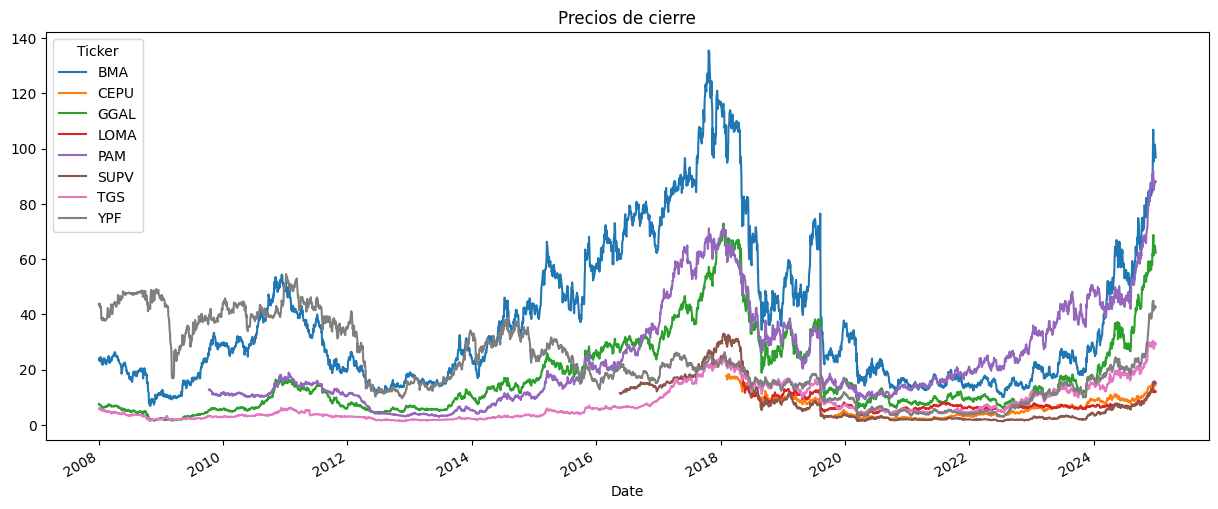

In [115]:
import matplotlib.pyplot as plt

data.plot(figsize=(15, 6), title='Precios de cierre')
plt.show()

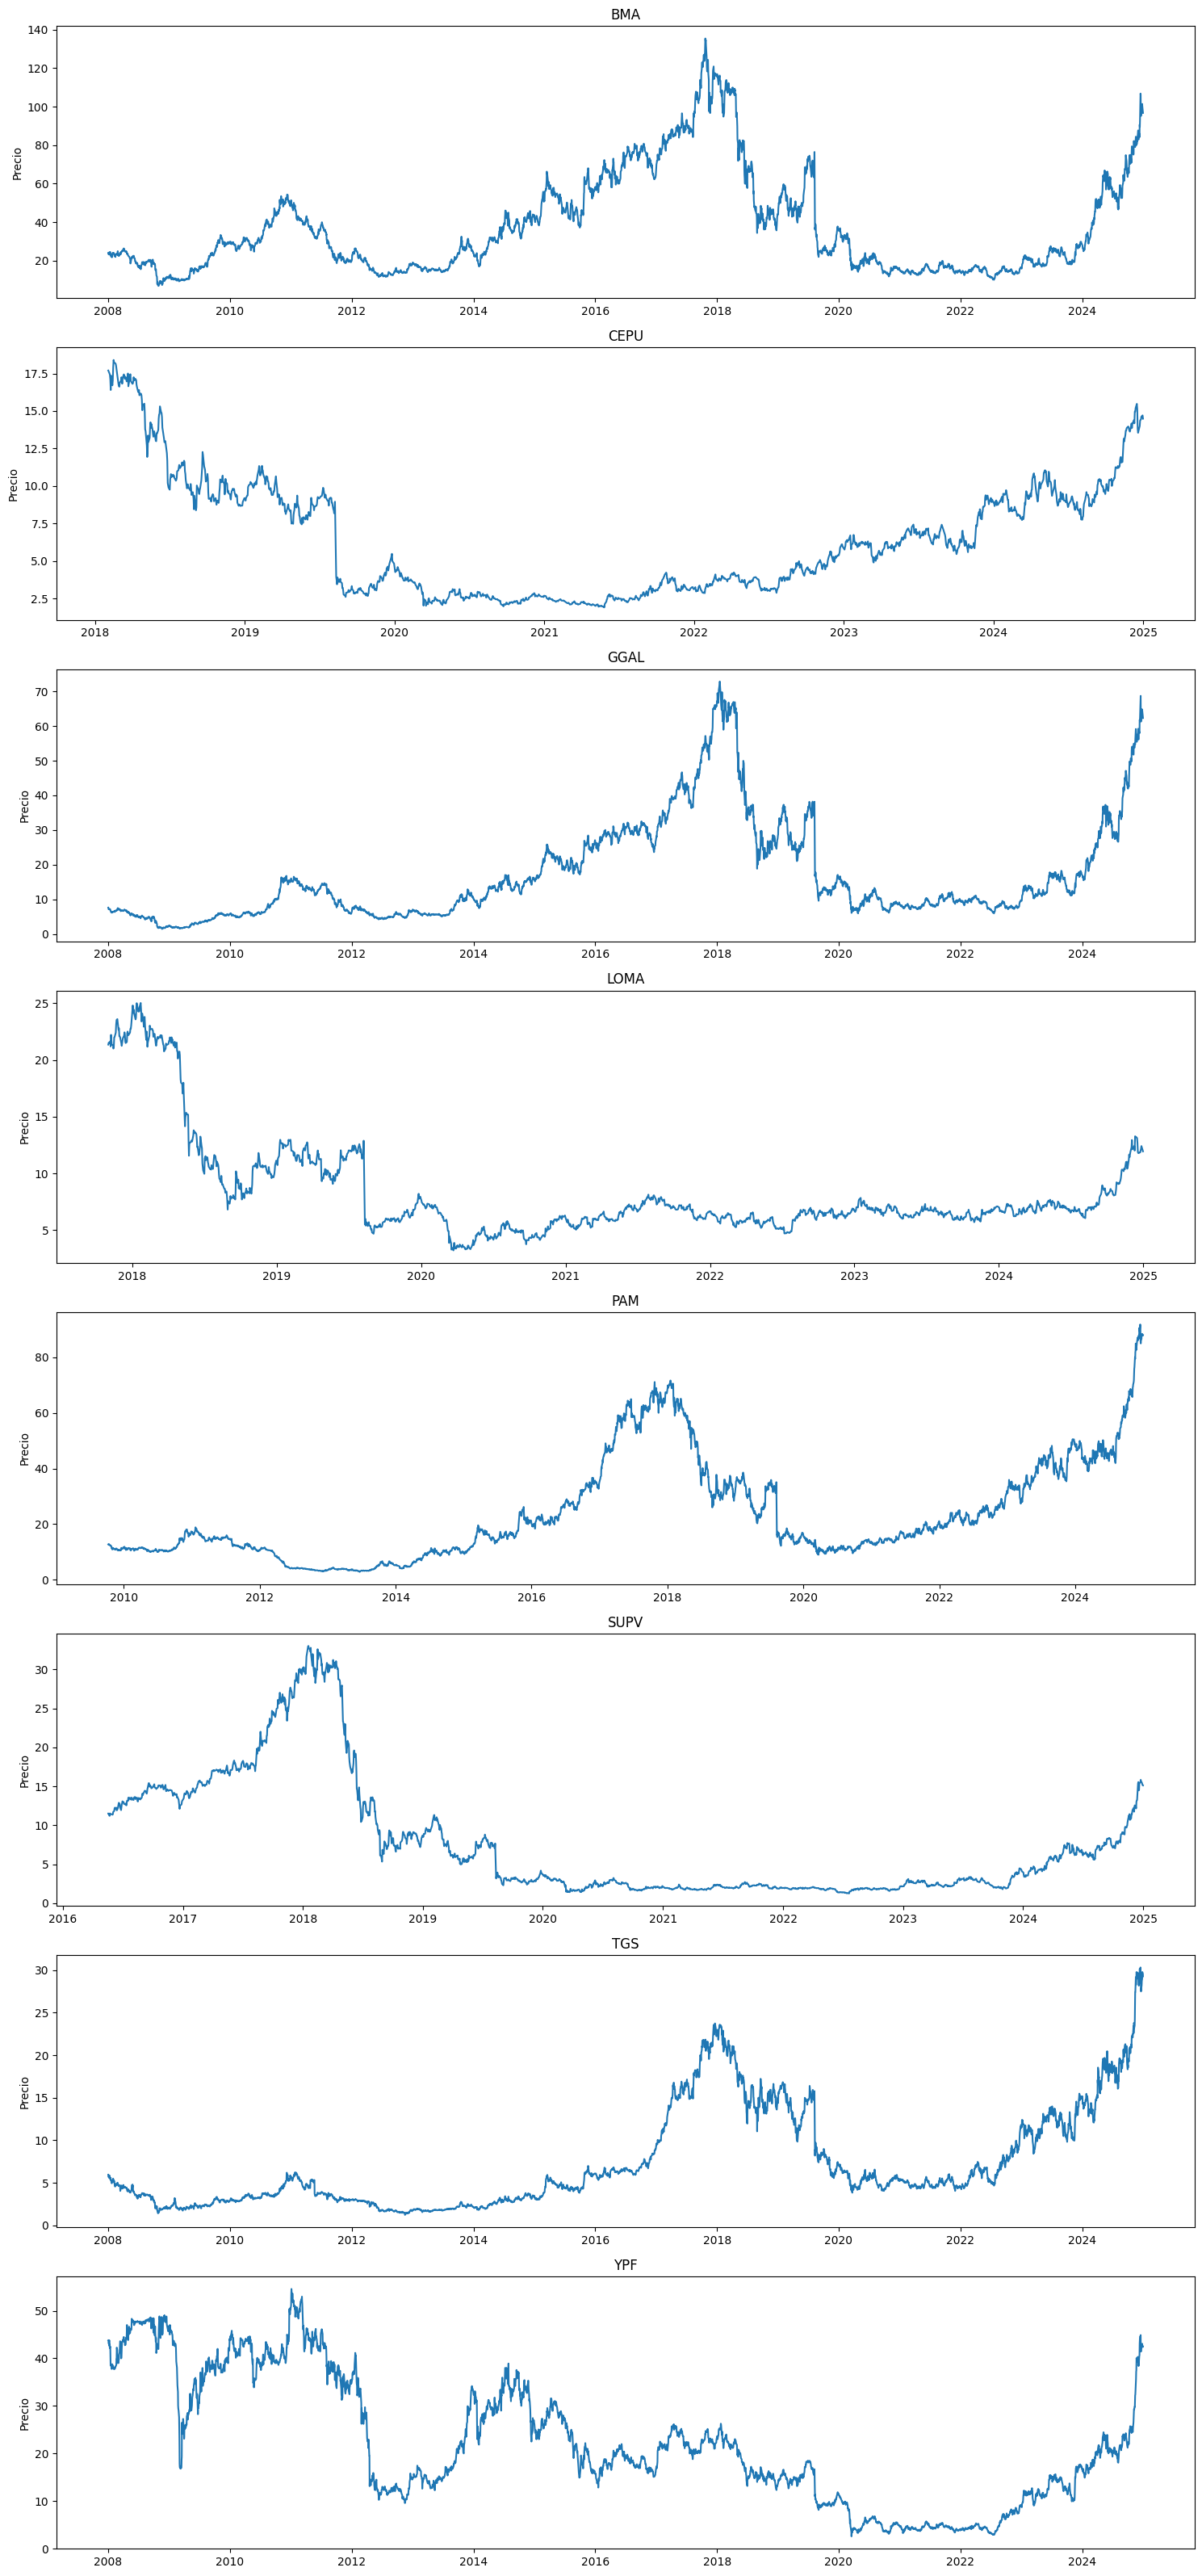

In [116]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Precio')

plt.tight_layout()
plt.show()

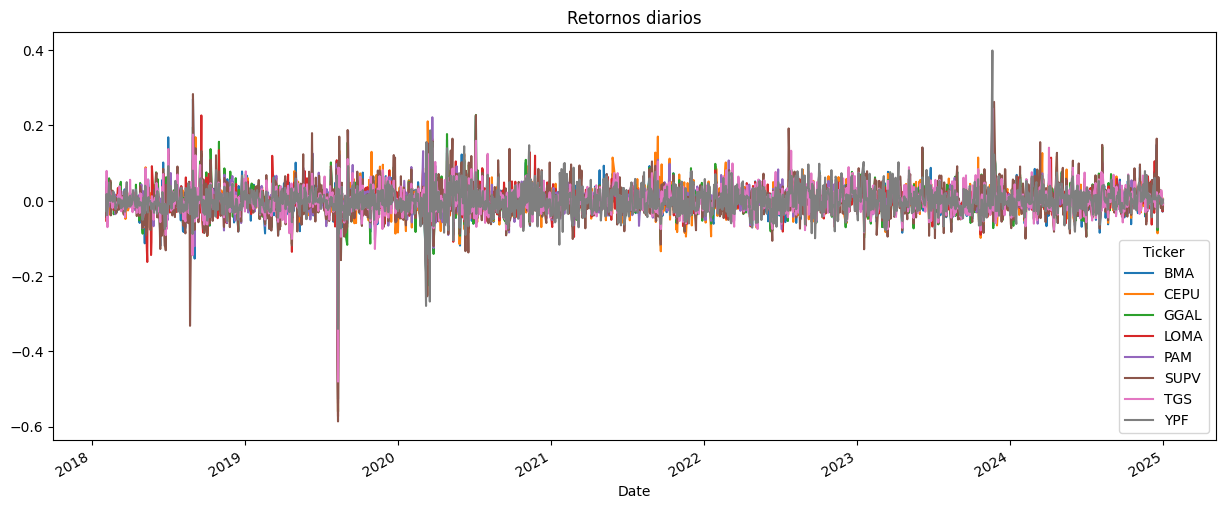

In [117]:
returns = data.pct_change().dropna()
returns.plot(figsize=(15, 6), title='Retornos diarios')
plt.show()

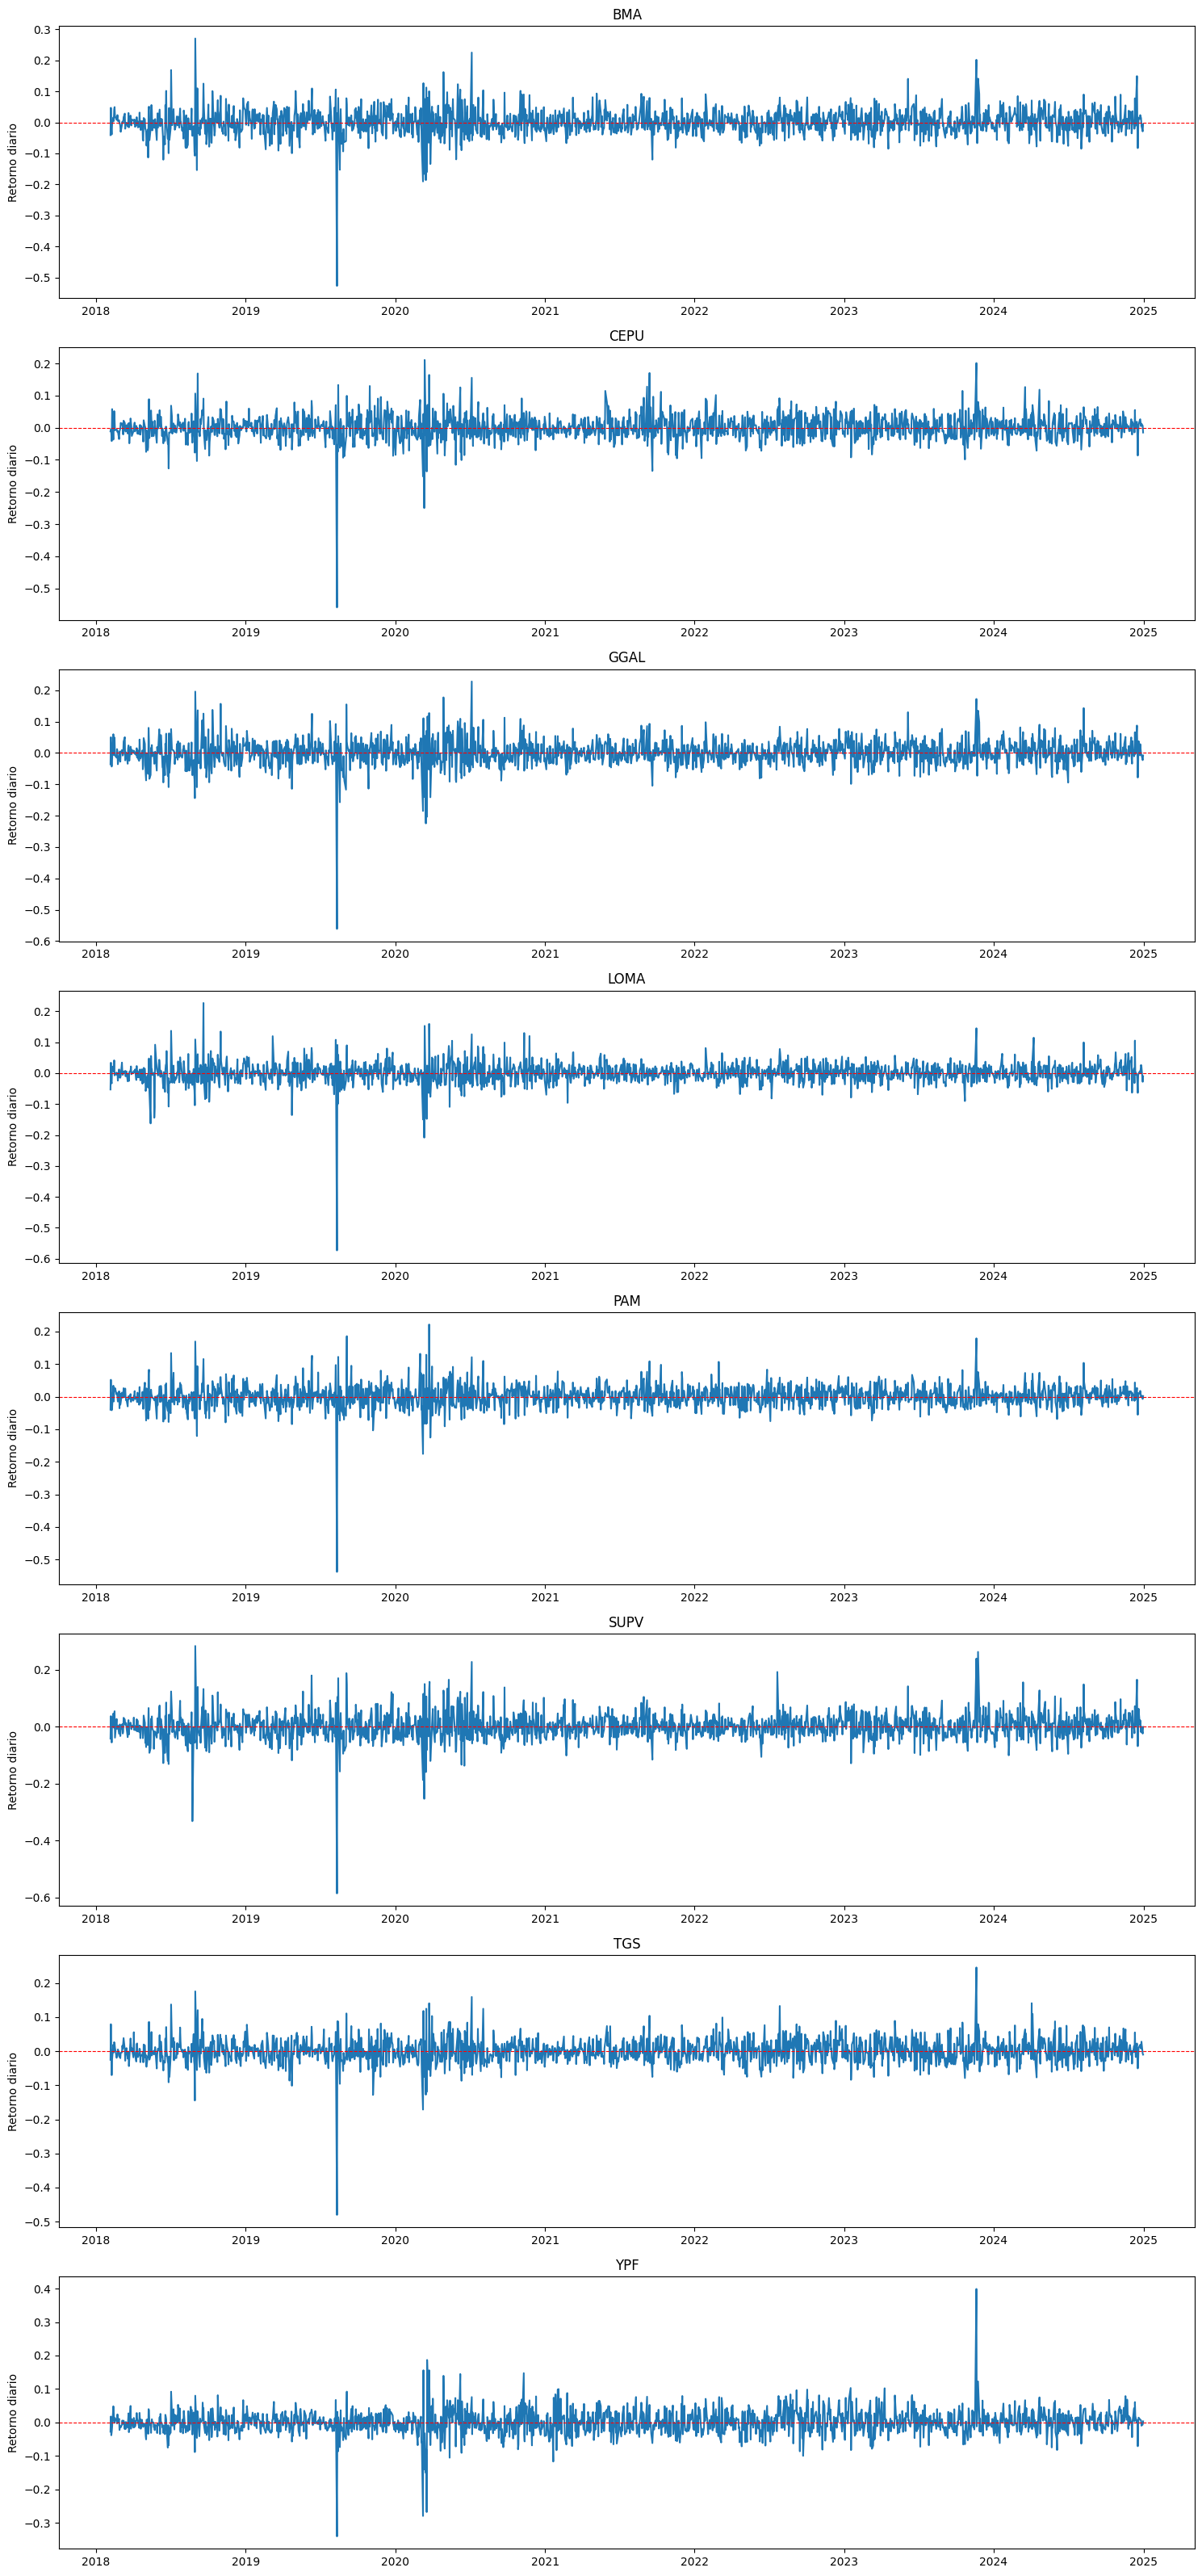

In [118]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(15, 4 * len(returns.columns)))

for i, ticker in enumerate(returns.columns):
    axes[i].plot(returns.index, returns[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Retorno diario')
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## Filtro de media movil


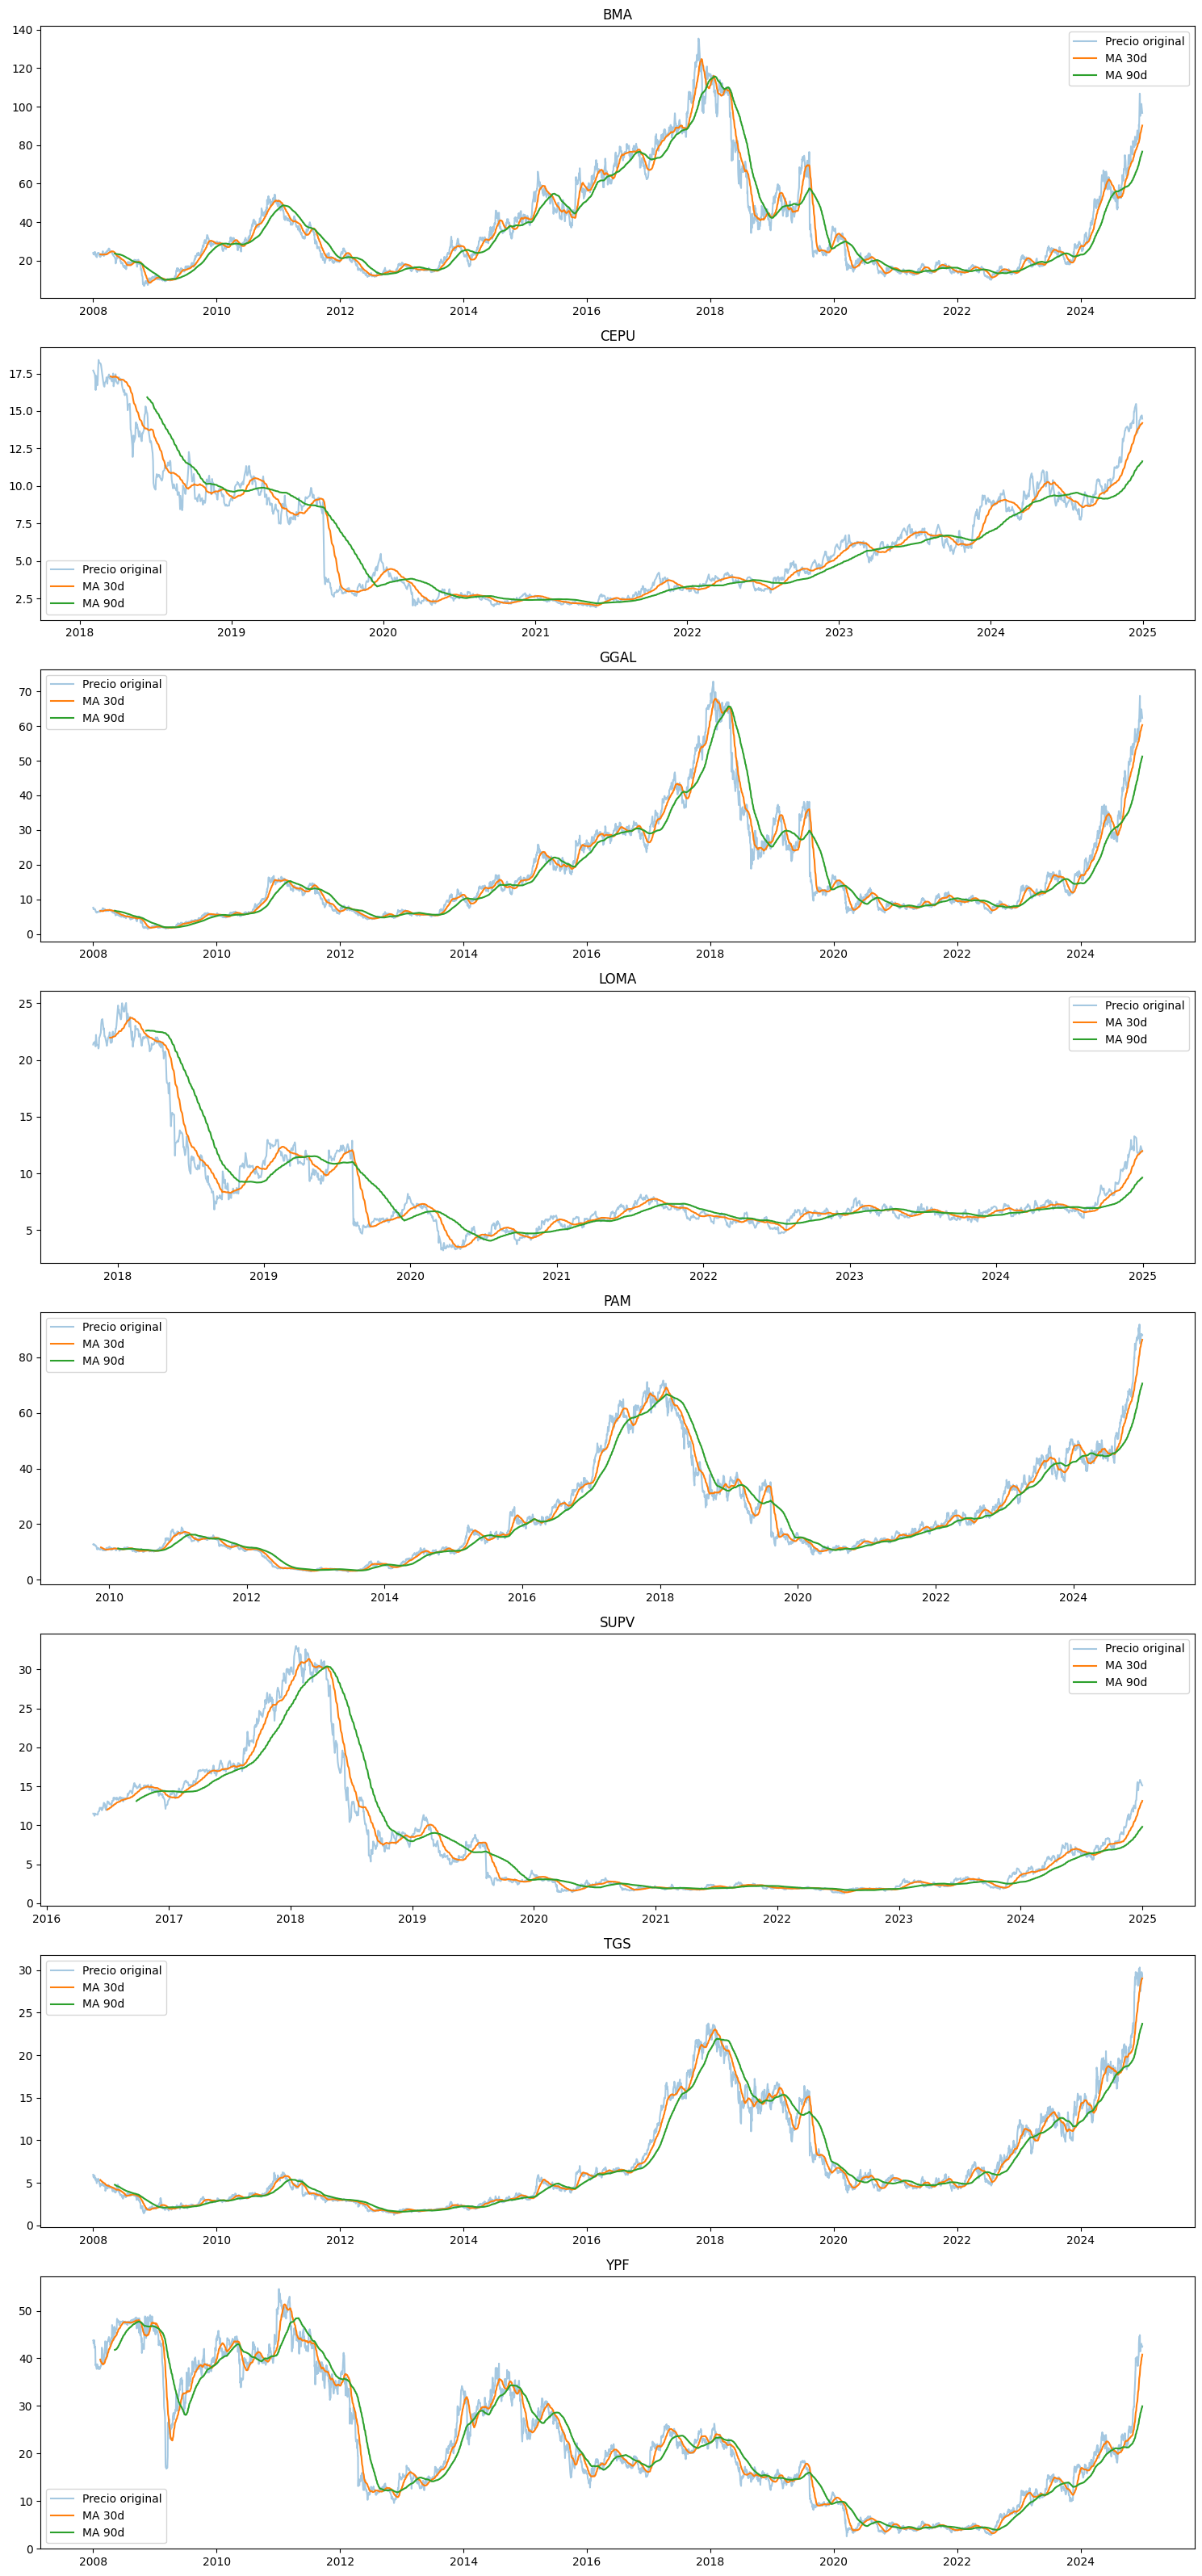

In [119]:
fig, axes = plt.subplots(len(data.columns), 1, figsize=(15, 4 * len(data.columns)))

ventanas = [30, 90]  # 1 mes y 3 meses

for i, ticker in enumerate(data.columns):
    axes[i].plot(data.index, data[ticker], alpha=0.4, label='Precio original')
    
    for ventana in ventanas:
        ma = data[ticker].rolling(window=ventana).mean()
        axes[i].plot(data.index, ma, label=f'MA {ventana}d')
    
    axes[i].set_title(ticker)
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Cuando la media movil corta (30 dias) corta a las larga (90 dias) hacia arriba -> la tendencia reciente es mas fuerte que la tendencia de fondo (alcista)
#### Cuando corta habia abajo -> la reciente es mas debir que la de fondo (bajista)


##### Veo que las empresas argentinas muestran señales de estar en tendencia alcista, miestras que meli entro en bajista hace unos mesas

## Veamos la FFT y filtremos las frecuencias altas para reducir el ruido

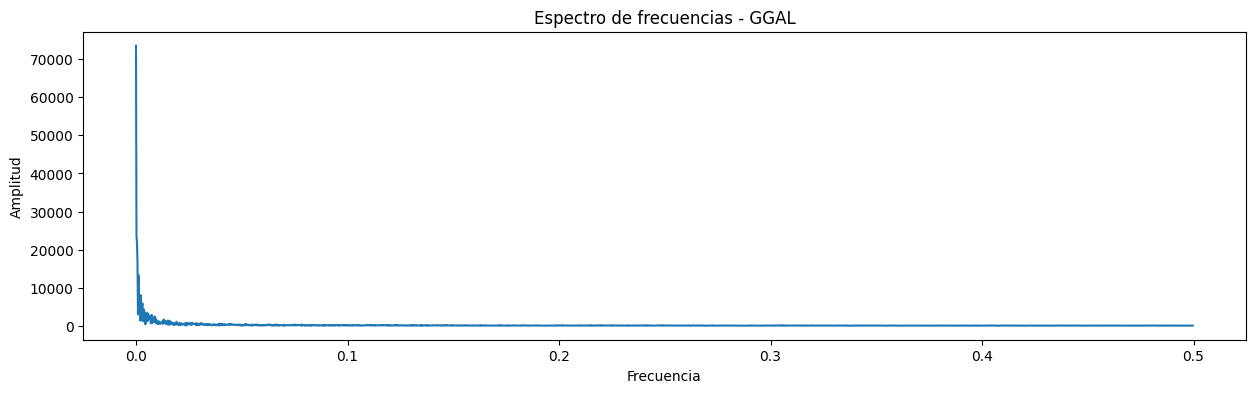

In [120]:
import numpy as np

ticker = 'GGAL'
precios = data[ticker].dropna().values

# Aplicamos FFT
fft = np.fft.fft(precios)
frecuencias = np.fft.fftfreq(len(precios))

# Graficamos el espectro de frecuencias
plt.figure(figsize=(15, 4))
plt.plot(frecuencias[:len(frecuencias)//2], 
         np.abs(fft[:len(fft)//2]))
plt.title(f'Espectro de frecuencias - {ticker}')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.show()

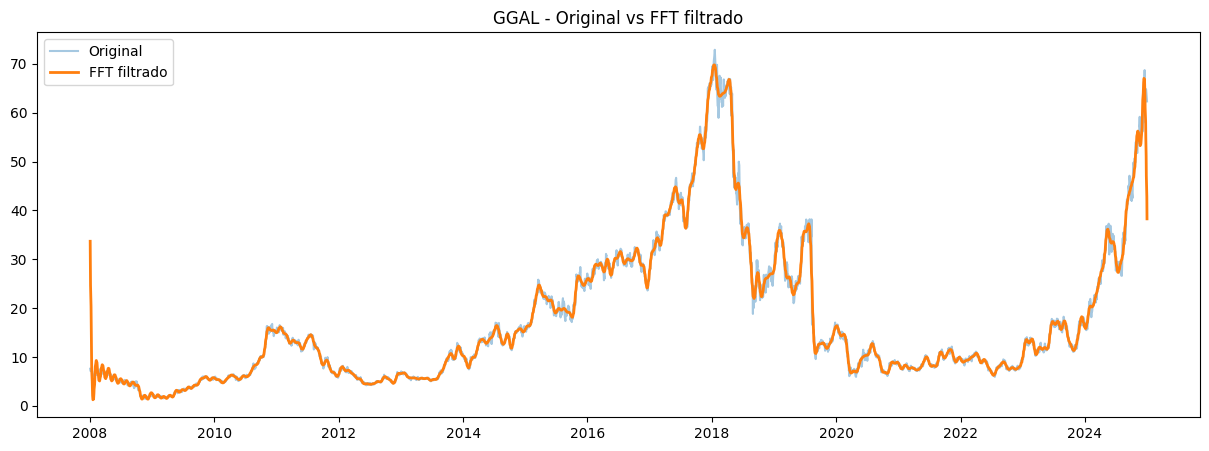

In [121]:
# Copiamos el resultado de la FFT
fft_filtrado = fft.copy()

# Umbral - eliminamos frecuencias altas
umbral = 0.04
fft_filtrado[np.abs(frecuencias) > umbral] = 0

# Reconstruimos la señal con IFFT
precio_filtrado = np.fft.ifft(fft_filtrado).real

# Comparamos original vs filtrado
plt.figure(figsize=(15, 5))
plt.plot(data.index[data[ticker].notna()], precios, alpha=0.4, label='Original')
plt.plot(data.index[data[ticker].notna()], precio_filtrado, label='FFT filtrado', linewidth=2)
plt.title(f'{ticker} - Original vs FFT filtrado')
plt.legend()
plt.show()

In [122]:
from scipy.signal import butter, filtfilt
import numpy as np

def butterworth_filter(data, cutoff, fs=1, order=4):
    nyq = fs / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

# Filtrado rolling - solo usa historia disponible hasta cada punto
fechas = data.index[data[ticker].notna()]
precios = data[ticker].dropna().values
precio_filtrado_rolling = []

for i in range(len(precios)):
    if i < 30:
        precio_filtrado_rolling.append(np.nan)
    else:
        segmento = precios[:i+1]
        filtrado = butterworth_filter(segmento, cutoff=0.05)
        precio_filtrado_rolling.append(filtrado[-1])

precio_filtrado = np.array(precio_filtrado_rolling)

# Eliminamos los primeros 30 dias
mask = ~np.isnan(precio_filtrado)
precio_filtrado = precio_filtrado[mask]
precios = precios[mask]
fechas = fechas[mask]

### con la señal filtrada puedo ver las tendencias en base a  la derivada


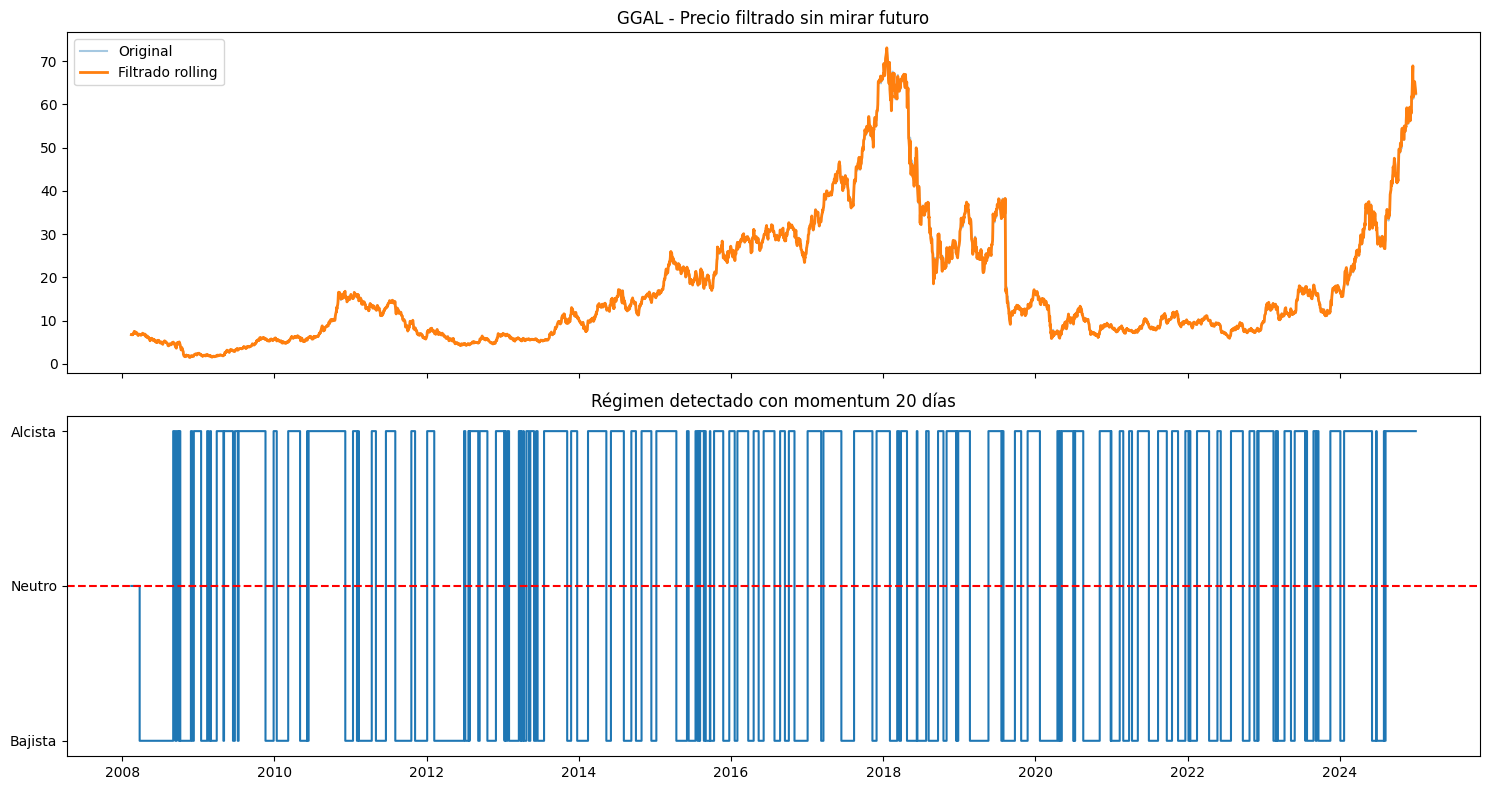

In [123]:
# Usamos el precio_filtrado rolling calculado antes
# NO volver a hacer: precio_filtrado = butterworth_filter(precios, cutoff=0.05)

precio_filtrado_s = pd.Series(precio_filtrado, index=fechas)

# Tendencia de 20 ruedas
momentum_20 = precio_filtrado_s.pct_change(20)

# Umbral: exige al menos +/- 3% en 20 ruedas para cambiar de régimen
umbral = 0.03

regimen = pd.Series(index=fechas, dtype=float)

regimen[momentum_20 > umbral] = 1
regimen[momentum_20 < -umbral] = -1

# Si está en zona neutra, mantiene el último régimen conocido
regimen = regimen.ffill()

# Al principio puede haber NaN por pct_change(20)
regimen = regimen.fillna(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(fechas, precios, alpha=0.4, label='Original')
ax1.plot(fechas, precio_filtrado, label='Filtrado rolling', linewidth=2)
ax1.set_title(f'{ticker} - Precio filtrado sin mirar futuro')
ax1.legend()

ax2.step(fechas, regimen, where='post')
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_title('Régimen detectado con momentum 20 días')
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Bajista', 'Neutro', 'Alcista'])

plt.tight_layout()
plt.show()

In [124]:
# Identificamos los cambios de regimen
regimen_values = regimen.to_numpy()

cambios = np.where(np.diff(regimen_values) != 0)[0] + 1

# Agregamos inicio y fin
breakpoints = np.concatenate([[0], cambios, [len(regimen_values)]])

# Calculamos duracion y tipo de cada regimen
regimenes = []

for i in range(len(breakpoints) - 1):
    inicio = breakpoints[i]
    fin = breakpoints[i + 1]
    duracion = fin - inicio

    tipo = regimen.iloc[inicio]

    if tipo == 1:
        tipo_nombre = 'alcista'
    elif tipo == -1:
        tipo_nombre = 'bajista'
    else:
        tipo_nombre = 'neutro'

    regimenes.append({
        'inicio': fechas[inicio],
        'fin': fechas[fin - 1],
        'duracion': duracion,
        'tipo': tipo_nombre
    })

df_regimenes = pd.DataFrame(regimenes)
print(df_regimenes)

        inicio        fin  duracion     tipo
0   2008-02-14 2008-03-24        26   neutro
1   2008-03-25 2008-08-29       112  bajista
2   2008-09-02 2008-09-11         8  alcista
3   2008-09-12 2008-09-18         5  bajista
4   2008-09-19 2008-09-26         6  alcista
..         ...        ...       ...      ...
200 2024-06-24 2024-06-25         2  alcista
201 2024-06-26 2024-07-30        24  bajista
202 2024-07-31 2024-08-01         2  alcista
203 2024-08-02 2024-08-07         4  bajista
204 2024-08-08 2024-12-31       101  alcista

[205 rows x 4 columns]


In [125]:
for tipo in ['alcista', 'bajista']:
    subset = df_regimenes[df_regimenes['tipo'] == tipo]['duracion']
    print(f"{tipo}:")
    print(f"  Promedio: {subset.mean():.1f} días")
    print(f"  Varianza: {subset.var():.1f}")
    print(f"  Mínimo:   {subset.min()} días")
    print(f"  Máximo:   {subset.max()} días")
    print(f"  Cantidad: {len(subset)} regímenes")
    print()

alcista:
  Promedio: 22.2 días
  Varianza: 563.3
  Mínimo:   1 días
  Máximo:   123 días
  Cantidad: 102 regímenes

bajista:
  Promedio: 19.2 días
  Varianza: 360.2
  Mínimo:   1 días
  Máximo:   112 días
  Cantidad: 102 regímenes



### hay mucha varianza en los regimenes alcistas como para predecir bien solo con esto cuanto tiempo va a durar

### Buscamos 

###  Features técnicas — vienen de la propia señal de precios
###  Features macro — contexto externo

Reversión a la media es la idea de que los precios (o en este caso las duraciones) tienden a volver a su promedio histórico con el tiempo.

## Construimos el dataframe completo

In [126]:
# Partimos del regimen que ya calculaste
df_features = pd.DataFrame(index=fechas)

df_features['precio'] = precios
df_features['precio_filtrado'] = precio_filtrado
df_features['regimen'] = regimen.values

# Dias transcurridos en el regimen actual
dias_en_regimen = []
contador = 0

for i in range(len(df_features)):
    if i == 0 or df_features['regimen'].iloc[i] == df_features['regimen'].iloc[i - 1]:
        contador += 1
    else:
        contador = 1
        
    dias_en_regimen.append(contador)

df_features['dias_en_regimen'] = dias_en_regimen

# Serie filtrada
precio_filtrado_s = pd.Series(precio_filtrado, index=fechas)

# Pendiente porcentual de 20 ruedas
df_features['pendiente'] = precio_filtrado_s.pct_change(20)

# Retorno diario del precio filtrado
df_features['retorno_filtrado_1d'] = precio_filtrado_s.pct_change(1)

# Desviación estándar / volatilidad de 20 ruedas
df_features['precio_std_20'] = (
    df_features['retorno_filtrado_1d']
    .rolling(20)
    .std()
)

# Target: cambia el régimen dentro de los próximos 7 días
ventana = 7
target = []

for i in range(len(df_features)):
    if i + ventana >= len(df_features):
        target.append(np.nan)
    else:
        regimen_actual = df_features['regimen'].iloc[i]
        regimen_futuro = df_features['regimen'].iloc[i+1:i+ventana+1]
        
        cambio = (regimen_futuro != regimen_actual).any()
        target.append(int(cambio))

df_features['target'] = target

df_features = df_features.dropna(subset=['target'])
df_features['target'] = df_features['target'].astype(int)

print(df_features.head())
print(df_features.shape)

            precio  precio_filtrado  regimen  dias_en_regimen  pendiente  \
Date                                                                       
2008-02-14    6.70         6.725253      0.0                1        NaN   
2008-02-15    6.69         6.715686      0.0                2        NaN   
2008-02-19    6.69         6.715039      0.0                3        NaN   
2008-02-20    6.80         6.823320      0.0                4        NaN   
2008-02-21    6.68         6.702027      0.0                5        NaN   

            retorno_filtrado_1d  precio_std_20  target  
Date                                                    
2008-02-14                  NaN            NaN       0  
2008-02-15            -0.001422            NaN       0  
2008-02-19            -0.000096            NaN       0  
2008-02-20             0.016125            NaN       0  
2008-02-21            -0.017776            NaN       0  
(4242, 8)


In [127]:
# Volumen del ticker elegido
vol_ticker = volumen[ticker].copy()
vol_ticker.index = vol_ticker.index.tz_localize(None)
vol_ticker.name = 'volumen_acciones'

df_features = df_features.join(vol_ticker, how='left')
df_features['volumen_acciones'] = df_features['volumen_acciones'].ffill()

# Features de volumen
df_features['volumen_log'] = np.log1p(df_features['volumen_acciones'])

df_features['volumen_ret_1d'] = (
    df_features['volumen_acciones']
    .pct_change(1)
)

df_features['volumen_std_20'] = (
    df_features['volumen_ret_1d']
    .rolling(20)
    .std()
)

df_features['volumen_sube'] = (
    df_features['volumen_ret_1d'] > 0
).astype(int)

# Monto negociado aproximado en USD
df_features['monto_negociado_usd'] = (
    df_features['precio'] * df_features['volumen_acciones']
)

df_features['monto_negociado_usd_log'] = np.log1p(
    df_features['monto_negociado_usd']
)

In [128]:
# Fechas de elecciones nacionales argentinas
elecciones = pd.to_datetime([
    '2009-06-28',  # Generales 2009 (Legislativas - sin PASO)
    '2011-08-14',  # PASO 2011
    '2011-10-23',  # Generales 2011 (Presidenciales y legislativas)
    '2013-08-11',  # PASO 2013 legislativas
    '2013-10-27',  # Generales 2013 (Legislativas)
    '2015-08-09',  # PASO 2015
    '2015-10-25',  # Generales 2015 (Primera vuelta presidencial)
    '2015-11-22',  # Balotaje 2015 (Presidencial)
    '2017-08-13',  # PASO 2017 legislativas
    '2017-10-22',  # Generales 2017 (Legislativas)
    '2019-08-11',  # PASO 2019
    '2019-10-27',  # Generales 2019 (Presidenciales y legislativas)
    '2021-09-12',  # PASO 2021 legislativas
    '2021-11-14',  # Generales 2021 legislativas
    '2023-08-13',  # PASO 2023 presidenciales
    '2023-10-22',  # Generales 2023 presidenciales
    '2023-11-19',  # Balotaje 2023
    '2025-10-26',  # Generales 2025 legislativas (sin PASO)
])

tipo_eleccion = {
    '2009-06-28': 'legislativa',
    '2011-08-14': 'presidencial',
    '2011-10-23': 'presidencial',
    '2013-08-11': 'legislativa',
    '2013-10-27': 'legislativa',
    '2015-08-09': 'presidencial',
    '2015-10-25': 'presidencial',
    '2015-11-22': 'presidencial',
    '2017-08-13': 'legislativa',
    '2017-10-22': 'legislativa',
    '2019-08-11': 'presidencial',
    '2019-10-27': 'presidencial',
    '2021-09-12': 'legislativa',
    '2021-11-14': 'legislativa',
    '2023-08-13': 'presidencial',
    '2023-10-22': 'presidencial',
    '2023-11-19': 'presidencial',
    '2025-10-26': 'legislativa',
}
peso_eleccion = {
    'presidencial': 2,
    'legislativa': 0.5,
}
# Dias hasta la proxima eleccion para cada fecha
def dias_hasta_eleccion_ponderado(fecha):
    futuras = elecciones[elecciones > fecha]
    if len(futuras) == 0:
        return 999
    proxima = futuras.min()
    tipo = tipo_eleccion[str(proxima.date())]
    dias = (proxima - fecha).days
    return dias / peso_eleccion[tipo]

df_features['dias_hasta_eleccion'] = [
    dias_hasta_eleccion_ponderado(f) for f in df_features.index
]

In [129]:
# ETF argentino en USD: proxy de sentimiento hacia Argentina
argt = yf.download(
    'ARGT',
    start=start,
    end=end,
    auto_adjust=False
)['Close']

argt = argt.squeeze()
argt.index = argt.index.tz_localize(None)
argt.name = 'argt'

df_features = df_features.join(argt, how='left')
df_features['argt'] = df_features['argt'].ffill()

df_features['argt_ret_1d'] = df_features['argt'].pct_change(1)
df_features['argt_ret_5d'] = df_features['argt'].pct_change(5)
df_features['argt_sube'] = (df_features['argt_ret_1d'] > 0).astype(int)


[*********************100%***********************]  1 of 1 completed


In [130]:
# Tipo de cambio USD/ARS
usdars = yf.download(
    'ARS=X',
    start=start,
    end=end,
    auto_adjust=False
)['Close']

usdars = usdars.squeeze()
usdars.index = usdars.index.tz_localize(None)
usdars.name = 'usdars'

df_features = df_features.join(usdars, how='left')
df_features['usdars'] = df_features['usdars'].ffill()

# Features del tipo de cambio
df_features['usdars_ret_1d'] = df_features['usdars'].pct_change(1)
df_features['usdars_ret_5d'] = df_features['usdars'].pct_change(5)

df_features['usdars_std_20'] = (
    df_features['usdars_ret_1d']
    .rolling(20)
    .std()
)

[*********************100%***********************]  1 of 1 completed


In [131]:
df_features = df_features.join(gap_overnight, how='left')

df_features['gap_overnight_abs'] = df_features['gap_overnight'].abs()
df_features['gap_overnight_positivo'] = (
    df_features['gap_overnight'] > 0
).astype(int)

df_features['gap_overnight_grande'] = (
    df_features['gap_overnight_abs'] >= 0.01
).astype(int)

In [132]:
columnas_a_eliminar = [
    'precio',
    'precio_filtrado',
    'retorno_filtrado_1d',
    'volumen_acciones',
    'volumen_ret_1d',
    'monto_negociado_usd',
    'usdars',
    'argt'
]

df_features = df_features.drop(
    columns=[c for c in columnas_a_eliminar if c in df_features.columns]
)

df_features = df_features.dropna()

print(df_features.head())
print(df_features.isnull().sum())
print(df_features['target'].value_counts(normalize=True))

            regimen  dias_en_regimen  pendiente  precio_std_20  target  \
Date                                                                     
2011-03-10     -1.0               20  -0.103085       0.026357       0   
2011-03-11     -1.0               21  -0.049051       0.023776       0   
2011-03-14     -1.0               22  -0.067333       0.023662       0   
2011-03-15     -1.0               23  -0.127994       0.025792       0   
2011-03-16     -1.0               24  -0.131232       0.025890       0   

            volumen_log  volumen_std_20  volumen_sube  \
Date                                                    
2011-03-10    12.398349        1.003210             1   
2011-03-11    11.475234        0.989600             0   
2011-03-14    12.048840        0.993441             1   
2011-03-15    13.589740        1.256101             1   
2011-03-16    13.259689        1.254183             0   

            monto_negociado_usd_log  dias_hasta_eleccion  argt_ret_1d  \
Date    

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_features.drop(columns=['target'])
y = df_features['target']

print(X.columns.tolist())
print(X.head())

# Split temporal - no aleatorio
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
print(classification_report(y_test, predictions))

['regimen', 'dias_en_regimen', 'pendiente', 'precio_std_20', 'volumen_log', 'volumen_std_20', 'volumen_sube', 'monto_negociado_usd_log', 'dias_hasta_eleccion', 'argt_ret_1d', 'argt_ret_5d', 'argt_sube', 'usdars_ret_1d', 'usdars_ret_5d', 'usdars_std_20', 'gap_overnight', 'gap_overnight_abs', 'gap_overnight_positivo', 'gap_overnight_grande']
            regimen  dias_en_regimen  pendiente  precio_std_20  volumen_log  \
Date                                                                          
2011-03-10     -1.0               20  -0.103085       0.026357    12.398349   
2011-03-11     -1.0               21  -0.049051       0.023776    11.475234   
2011-03-14     -1.0               22  -0.067333       0.023662    12.048840   
2011-03-15     -1.0               23  -0.127994       0.025792    13.589740   
2011-03-16     -1.0               24  -0.131232       0.025890    13.259689   

            volumen_std_20  volumen_sube  monto_negociado_usd_log  \
Date                               

In [134]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import make_scorer, recall_score

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

scorer = make_scorer(recall_score)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring=scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor recall en CV:", grid_search.best_score_)

# Evaluamos en test
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test, predictions))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor recall en CV: 0.6049552763028461
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       506
           1       0.50      0.68      0.57       188

    accuracy                           0.73       694
   macro avg       0.68      0.71      0.69       694
weighted avg       0.76      0.73      0.74       694



pendiente                  0.452932
volumen_std_20             0.077261
dias_en_regimen            0.066085
dias_hasta_eleccion        0.063836
monto_negociado_usd_log    0.054605
precio_std_20              0.052796
volumen_log                0.050093
usdars_std_20              0.045922
argt_ret_5d                0.042096
usdars_ret_5d              0.027475
gap_overnight_abs          0.014721
regimen                    0.014071
usdars_ret_1d              0.012811
argt_ret_1d                0.012062
gap_overnight              0.010139
gap_overnight_positivo     0.001284
volumen_sube               0.000866
gap_overnight_grande       0.000496
argt_sube                  0.000450
dtype: float64


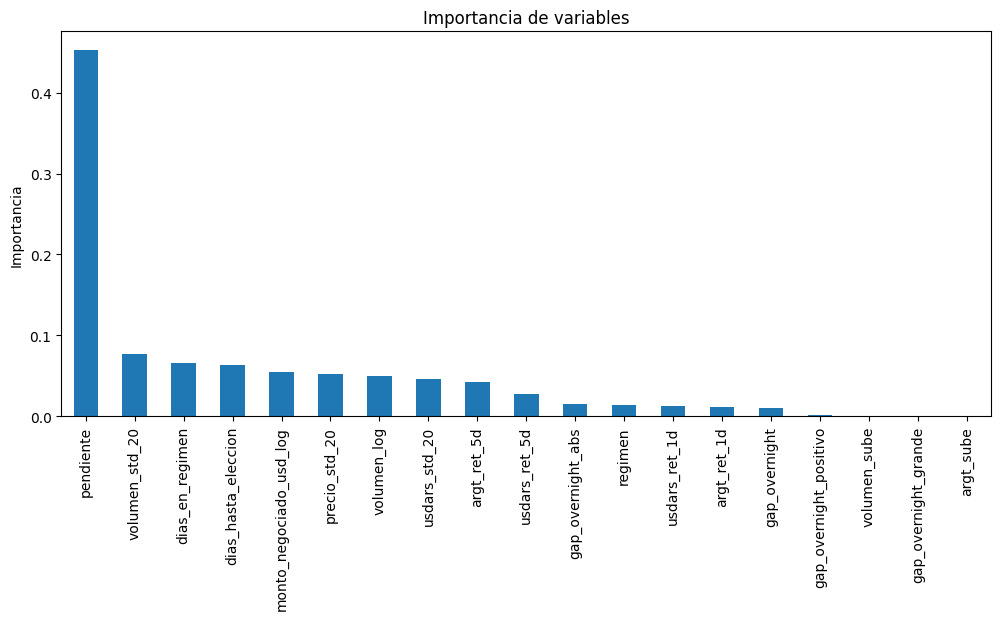

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importancias)

importancias.plot(kind='bar', figsize=(12, 5), title='Importancia de variables')
plt.ylabel('Importancia')
plt.show()

argentina tiene alta correlacion entre activs. si me mantengo entre activos locales cross activo no voy a conseguir mucha ventaja.

la veta es bastante similar

estaria bueno meter en el analisis el volumen(cantidad de acciones negociadas) y el tipo de cambio

# Analisis usando Mallat

Vimos que usando FFT podemos obtener hiperparametros importantes para usar dentro de nuestro Random Forest, para asi predecir si la tendencia es alcista o bajista, y mucho mas.

FFT en teoría nos dice qué frecuencias están presentes en la señal, pero **no nos dice en qué momento** ocurren.

Ahora bien, queremos experimentar usando otro algoritmo visto en clase llamado **Algoritmo Piramidal Mallat**.
Este algoritmo genera un analisis tiempo-frecuencia que permite captiurar simultaneamente informacion temporal y espectral. 

Este algoritmo consiste en:
1. Tomamos nuestra funcion que genera la acción, f(x)
2. Aplicamos un filtro
    - Por un lado, aplicamos pasa-altos, g(x)
    - Por otro lado, aplicamos pasa-bajos, h(x)
3. Dividimos nuestro sample por 2 (ejemplo el sample de 1000 dias pasa a ser de 1000/2 = 500)
4. Que sigue:
    - h(x) pasa a la proxima etapa (comienza de nuevo desde 1.)
    - g(x) genera la primera señal Detalle (D1)

Este algoritmo va extrayendo bandas de frecuencias, y va a seguir iterando hasta que nuestro sample llegue a 0 o lleguemos al nivel de detalle "n" que queriamos (Dn)


En la practica usamos la Transformada Waveled Discreta (DWT), asi que en este TP haremos lo mismo


---

Implementemoslo primero para GGAL

In [136]:
data.head()

Ticker,BMA,CEPU,GGAL,LOMA,PAM,SUPV,TGS,YPF
Date,,,,,,,,
2008-01-02,24.000000,NaN,7.60,NaN,NaN,NaN,5.96,43.770000
2008-01-03,23.400000,NaN,7.40,NaN,NaN,NaN,5.70,43.740002
2008-01-04,23.570000,NaN,7.14,NaN,NaN,NaN,5.70,43.119999
2008-01-07,23.290001,NaN,7.16,NaN,NaN,NaN,5.80,43.119999
2008-01-08,23.110001,NaN,7.09,NaN,NaN,NaN,5.56,43.799999


## Transformada Wavelet Discreta (DWT)

### Principio del algoritmo piramidal de Mallat

La DWT descompone la señal de forma iterativa mediante un banco de filtros:

1. Se aplica un **filtro pasa-bajos** → coeficientes de **aproximación** $C_j$
2. Se aplica un **filtro pasa-altos** → coeficientes de **detalle** $D_j$
3. Se submuestrea por 2 y se repite el proceso sobre $C_j$


En cada nivel $j$ se reduce a la mitad el número de muestras pero se duplica la resolución espectral de esa banda. El proceso termina cuando queda una sola muestra. Esto genera una representación jerárquica **tiempo-escala**(equivalente a tiempo-frecuencia).

Usamos **wavelets de Daubechies de fase extrema, orden 4** (DaubExPhase, filter.number = 4): un filtro compacto con buenas propiedades de regularidad y localización.

In [137]:
# Empecemos a crear nuestro Mallat usando los wavelets
import pywt

# Colores fijos por ticker (según leyenda del proyecto)
color_map = {
    'YPF': 'tab:blue',
    'GGAL': 'tab:orange',
    'BMA': 'tab:green',
    'SUPV': 'tab:red',
    'LOMA': 'tab:purple',
    'CEPU': 'tab:brown',
    'PAM': 'tab:pink',
    'TGS': 'tab:gray',
}

Primero definimos que tipo de wavelet vamos a usar.
En nuestro caso es 'db4' -> Daubechies con 4 niveles

In [138]:
# Implementación de la pirámide de Mallat, para TODOS los tickers

resultados_por_nivel_todos = {}

for ticker in tickers:
    precios_ticker = data[ticker].dropna().values  # nuestra señal actual
    señal_actual = precios_ticker.copy()            # copiamos la señal actual, pero esta se va a ir modificando mas tarde

    # El nivel de detalle que vamos a querer
    # Osea la cantidad de divisiones a la mitad que caben con nuestra cantidad de dias
    nivel_max = 7       # usamos nivel = 7 ya que hay acciones que son mas recientes y no sobreviven muchos downsamplings

    resultados_por_nivel = {}

    # Implementacion de la piramide de Mallat
    # Calculamos iterativamente cada cA y cD y lo guardamos en "resultados_por_nivel"
    for nivel in range(1, nivel_max + 1):
        # Calculamos cA, cD.
        cA, cD = pywt.dwt(señal_actual, wavelet)

        # Guardamos los resultados en "resultados_por_nivel"
        resultados_por_nivel[nivel] = {'cA': cA, 'cD': cD}

        # Re-iteramos con nuestra nueva señal Aproximacion cA
        señal_actual = cA

    # Una vez que salimos del ciclo, tenemos todos los niveles de detalle (cD) y aproximacion (cA) guardados en "resultados_por_nivel".
    resultados_por_nivel_todos[ticker] = {
        'resultados_por_nivel': resultados_por_nivel,
        'nivel_max': nivel_max,
        'precios': precios_ticker
    }

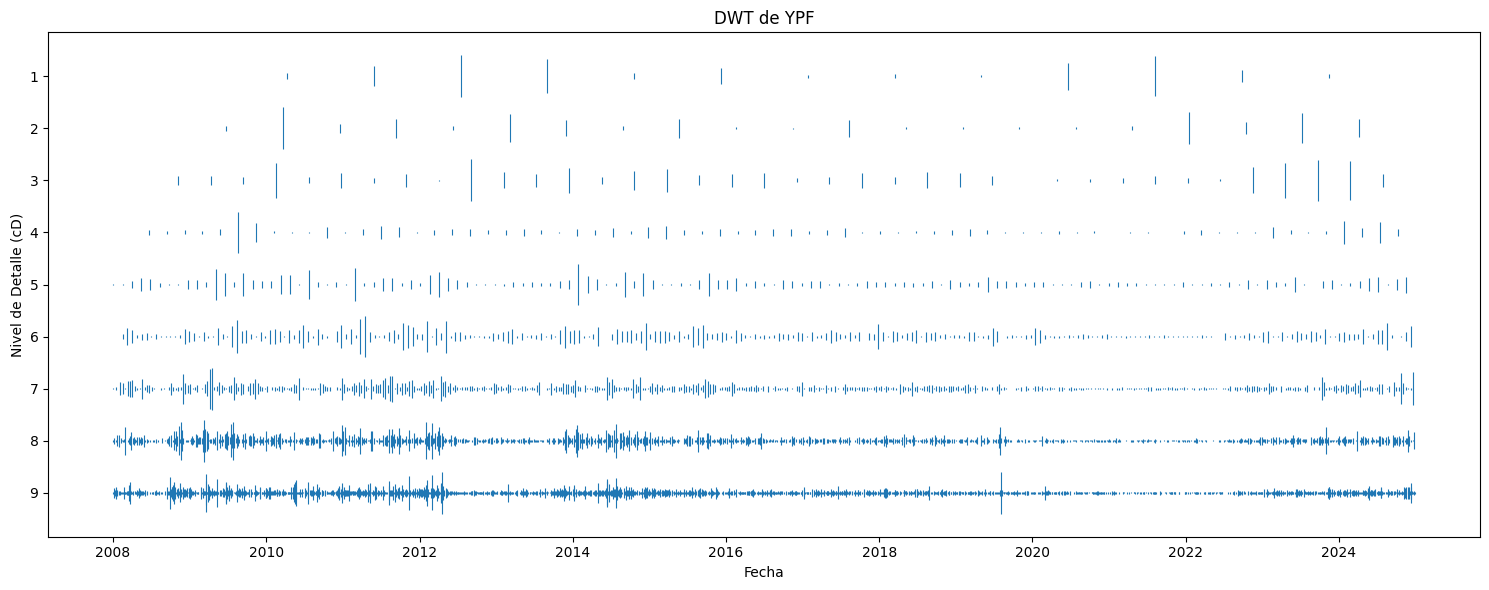

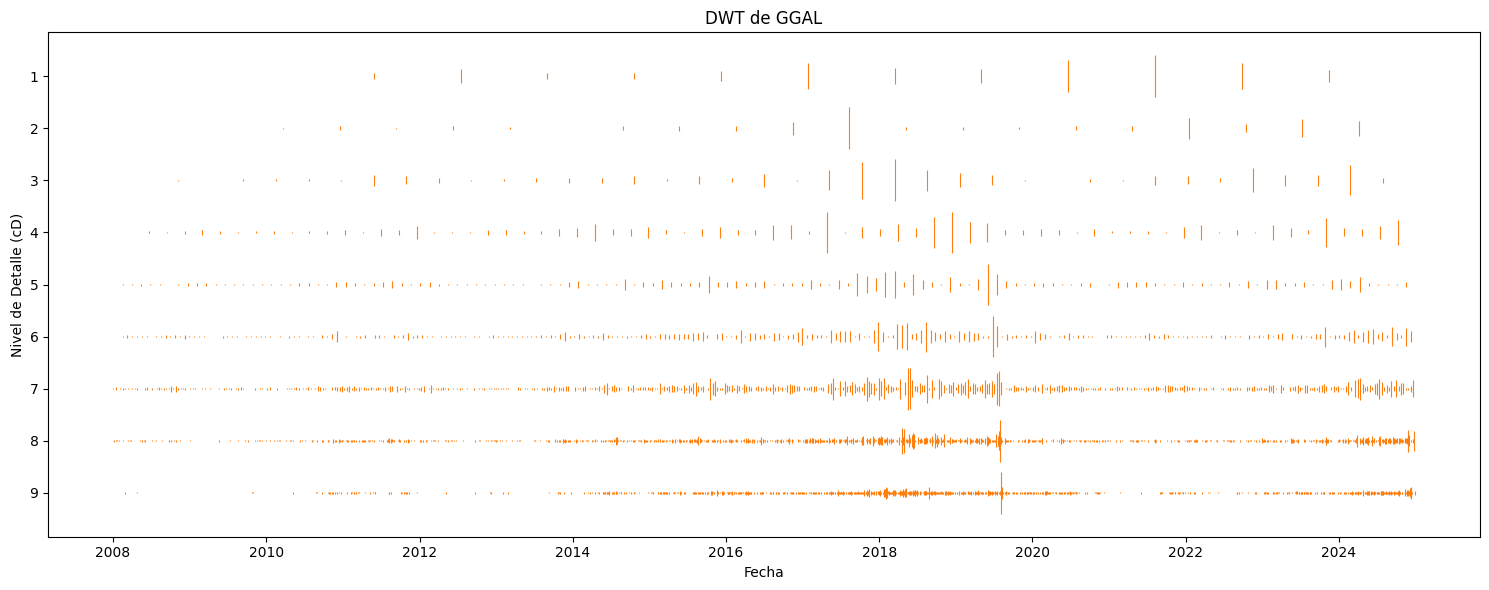

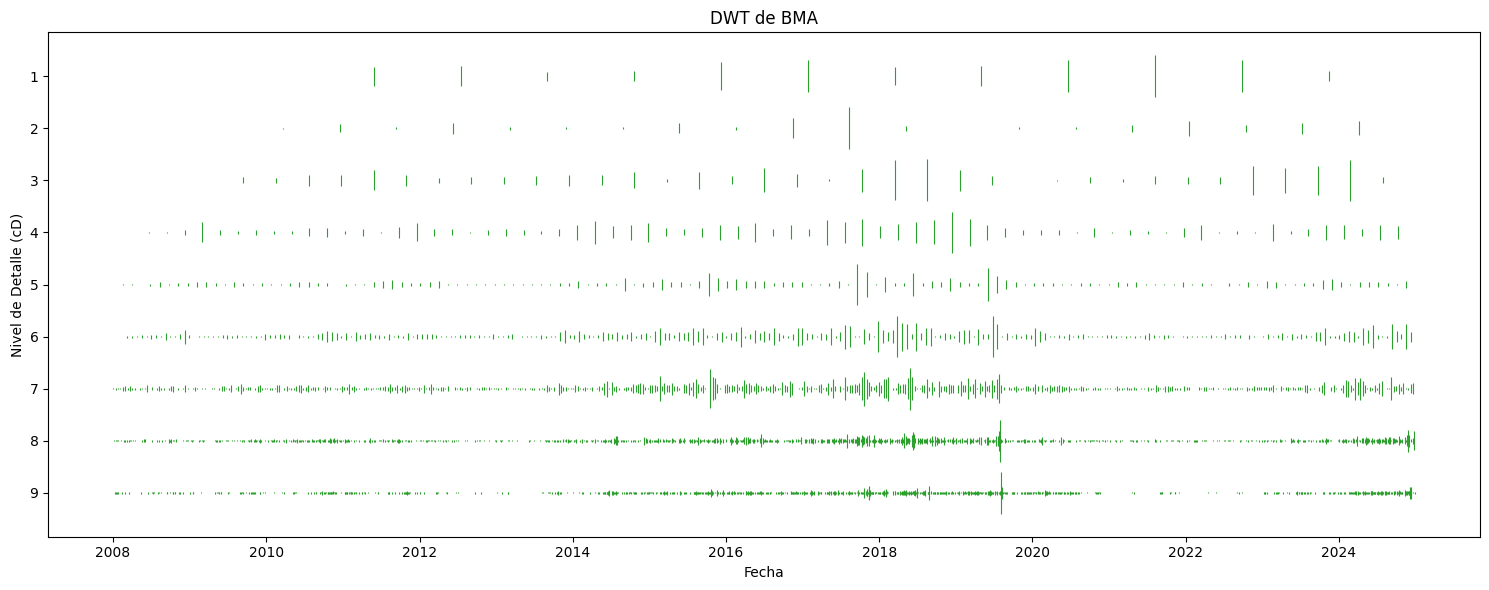

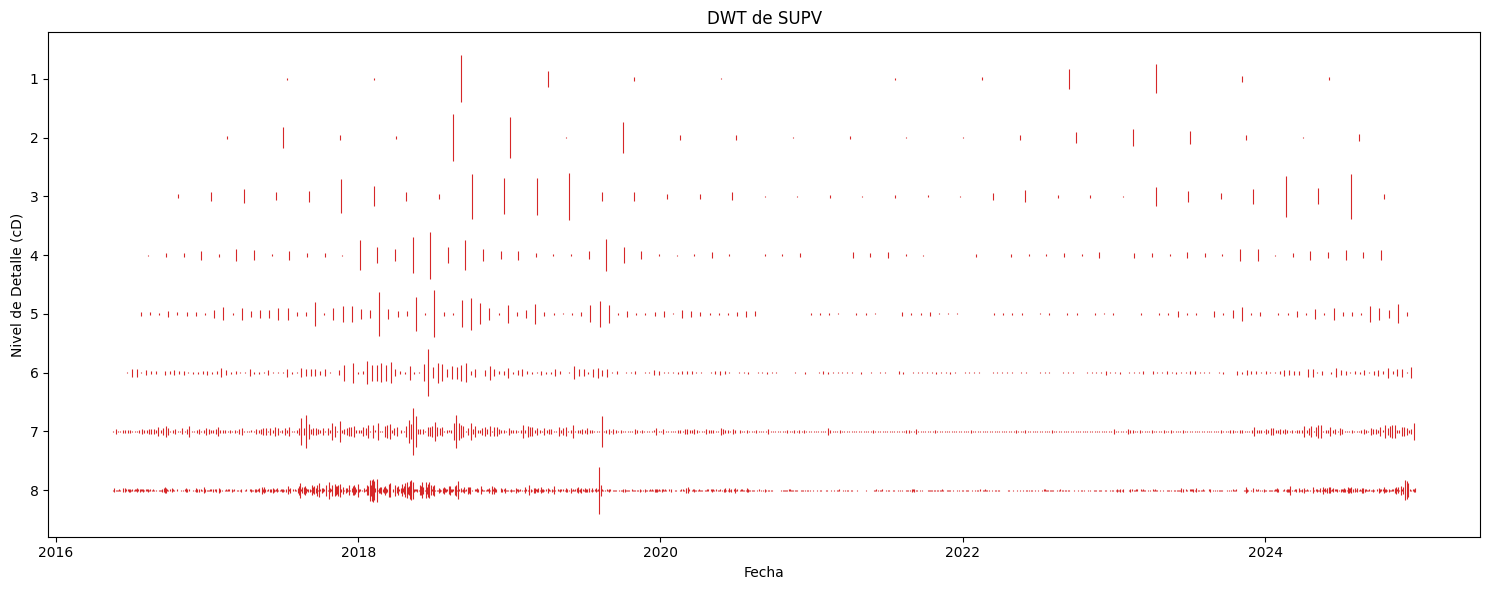

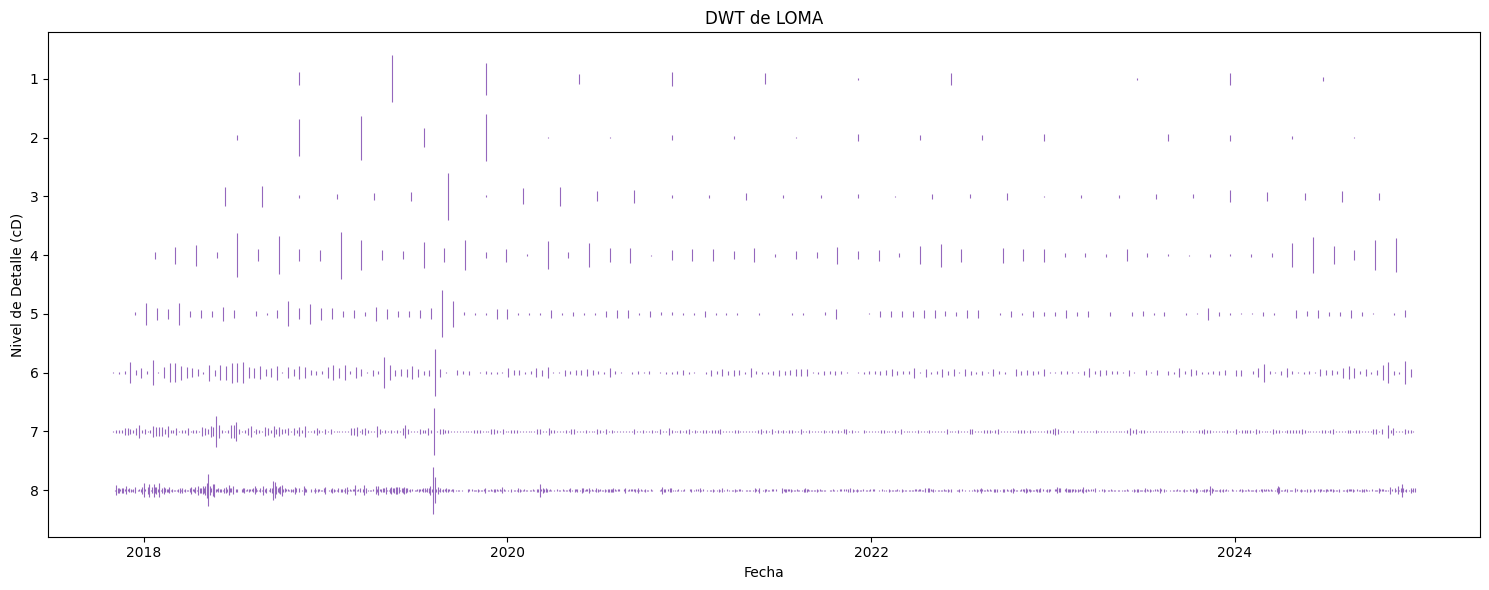

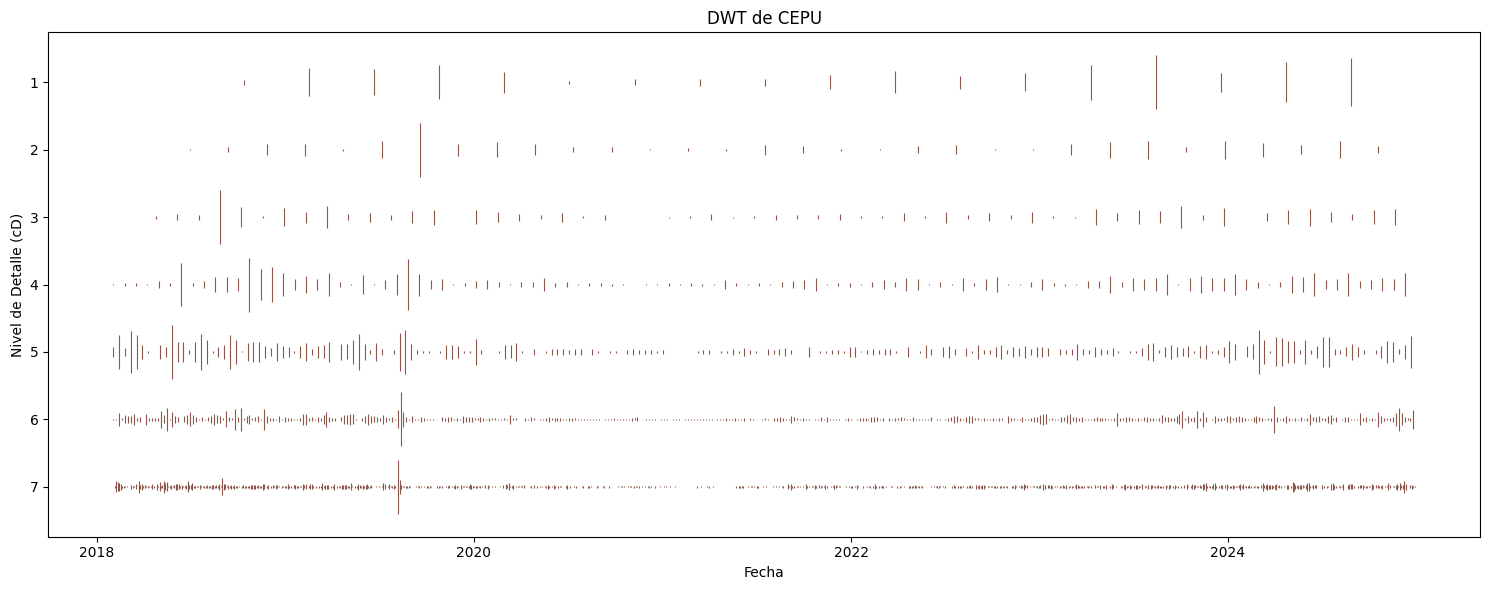

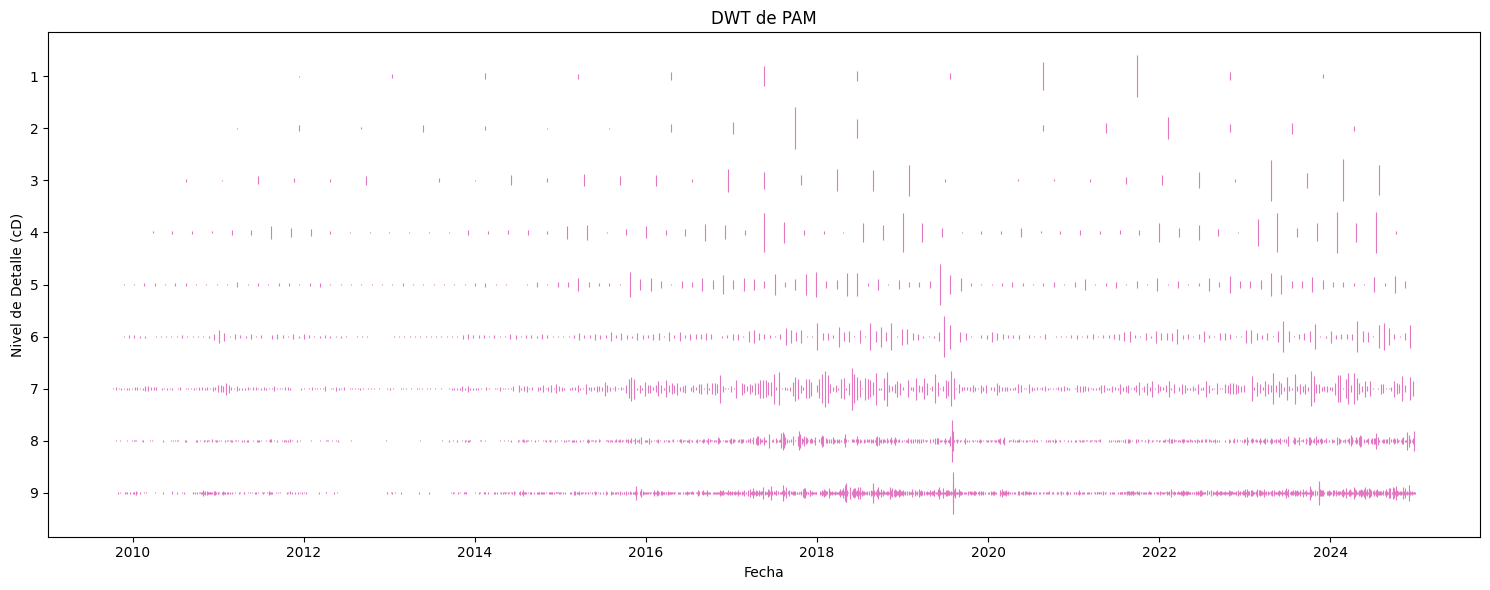

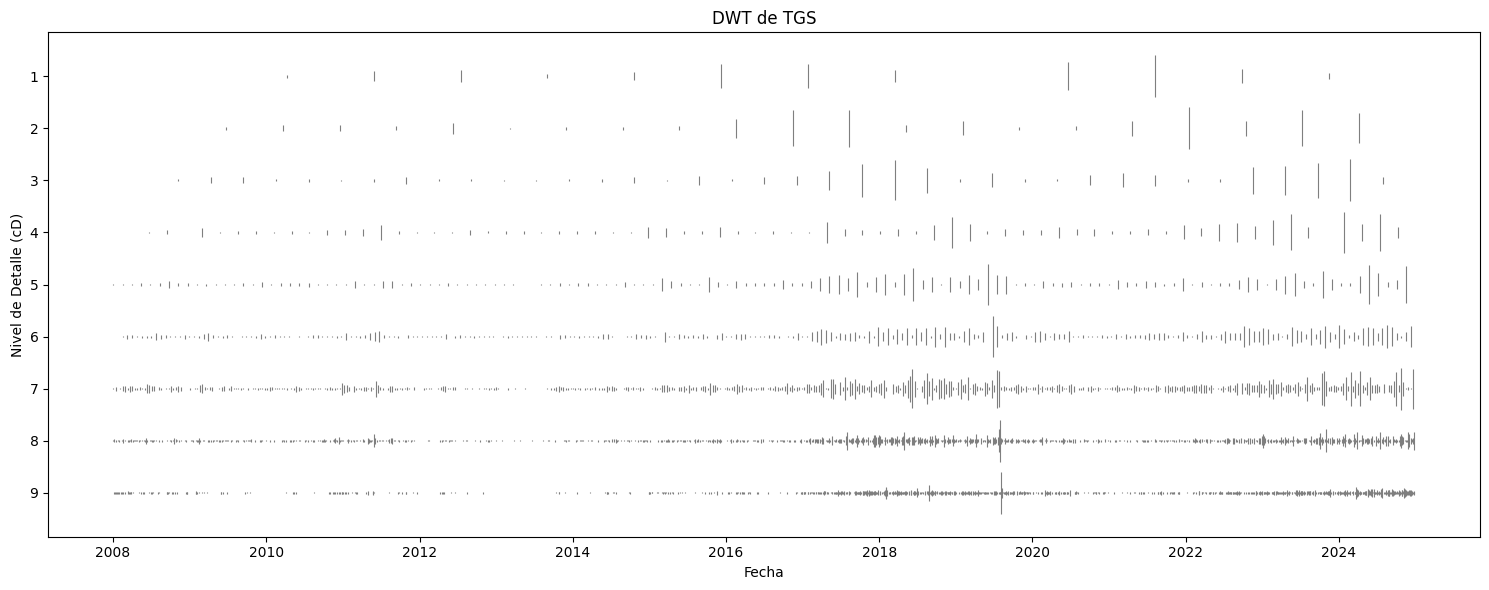

In [139]:
import matplotlib.dates as mdates

def plot_escalograma(coeffs, fechas, titulo='DWT', ax=None):
    cDs = coeffs[1:]  # detalles, sin la aproximación final
    n_niveles = len(cDs)

    fecha_inicio = fechas[0]
    fecha_fin = fechas[-1]
    total_segundos = (fecha_fin - fecha_inicio).total_seconds()

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    for i, cD in enumerate(cDs):
        fila_y = n_niveles - i

        posiciones_relativas = np.arange(len(cD)) / len(cD)
        posiciones = fecha_inicio + pd.to_timedelta(posiciones_relativas * total_segundos, unit='s')

        magnitudes = np.abs(cD) / (np.abs(cD).max() + 1e-9)

        ax.vlines(posiciones, fila_y - magnitudes * 0.4, fila_y + magnitudes * 0.4,
                   color=color_map[ticker], linewidth=0.8)

    ax.set_yticks(range(1, n_niveles + 1))
    ax.set_yticklabels([f'{n_niveles - i}' for i in range(n_niveles)])
    ax.set_ylabel('Nivel de Detalle (cD)')
    ax.set_xlabel('Fecha')
    ax.set_title(titulo)

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


for ticker in tickers:
    coeffs_ticker = pywt.wavedec(data[ticker].dropna().values, wavelet)
    fechas_ticker = data[ticker].dropna().index

    fig, ax = plt.subplots(figsize=(15, 6))
    plot_escalograma(coeffs_ticker, fechas_ticker, titulo=f'DWT de {ticker}', ax=ax)
    plt.tight_layout()
    plt.show()

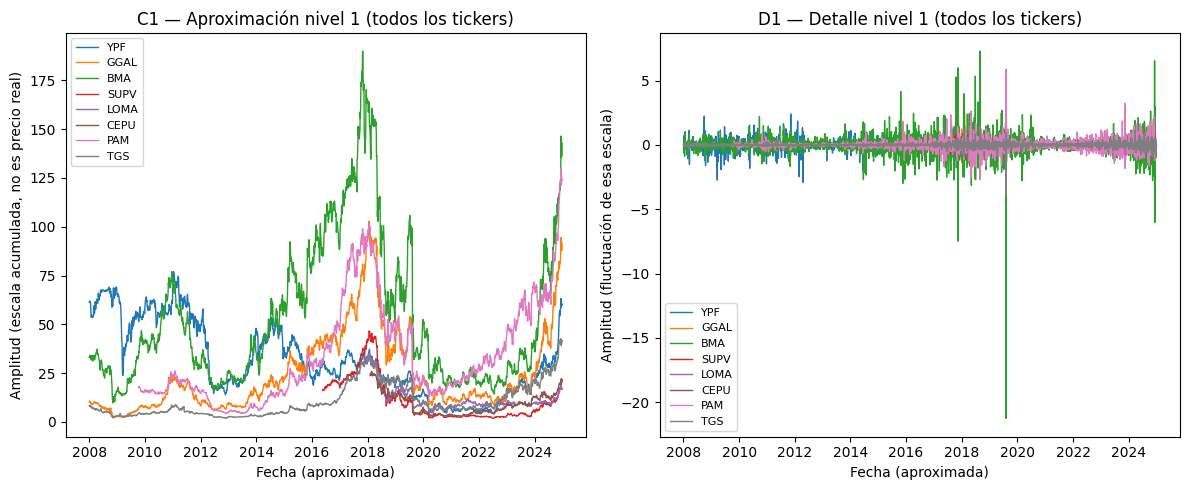

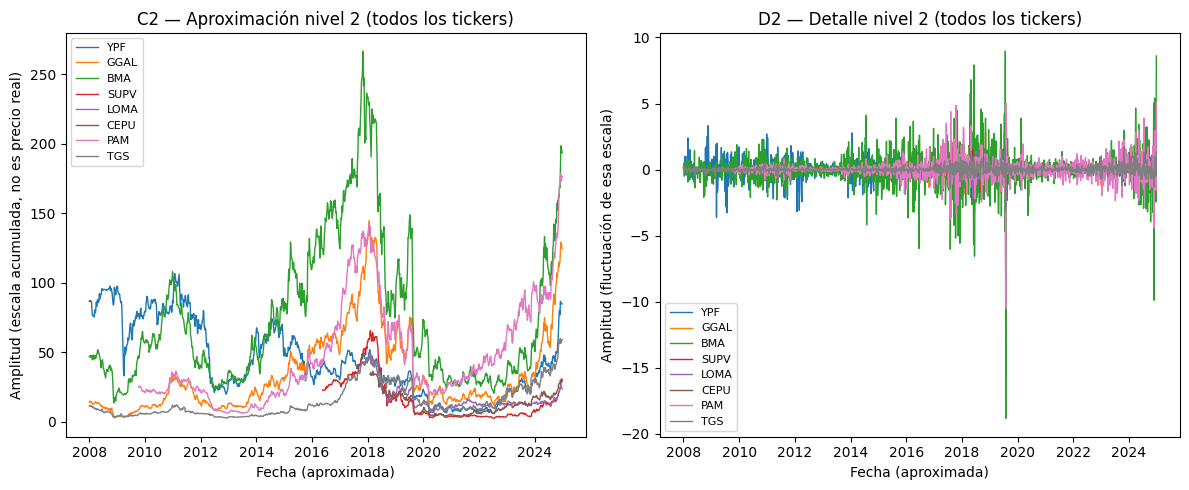

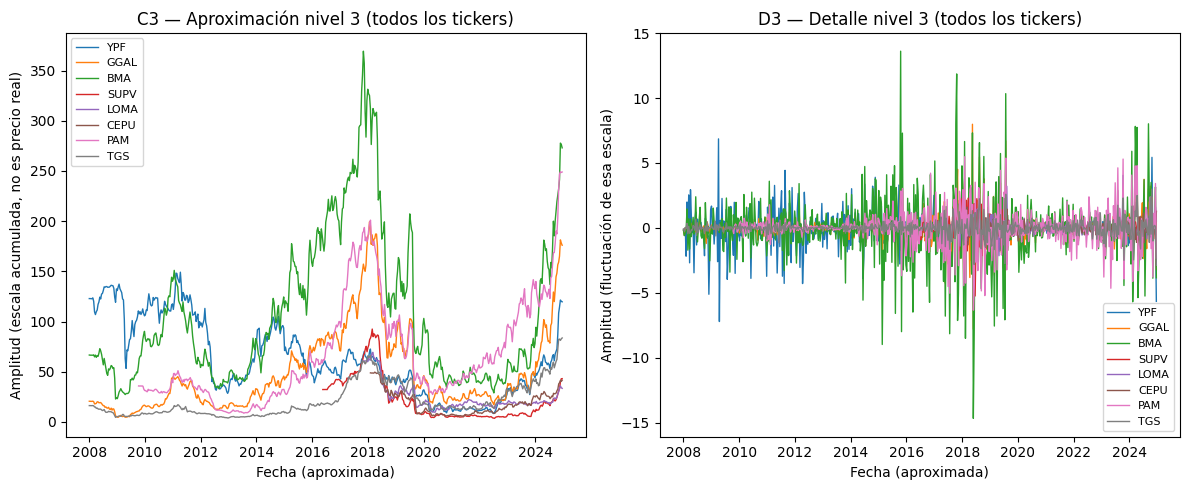

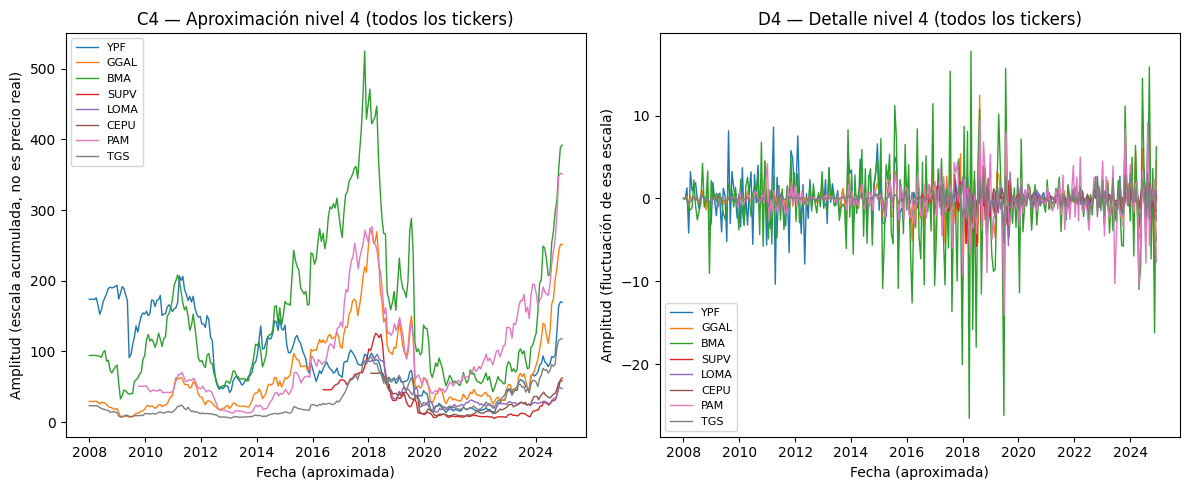

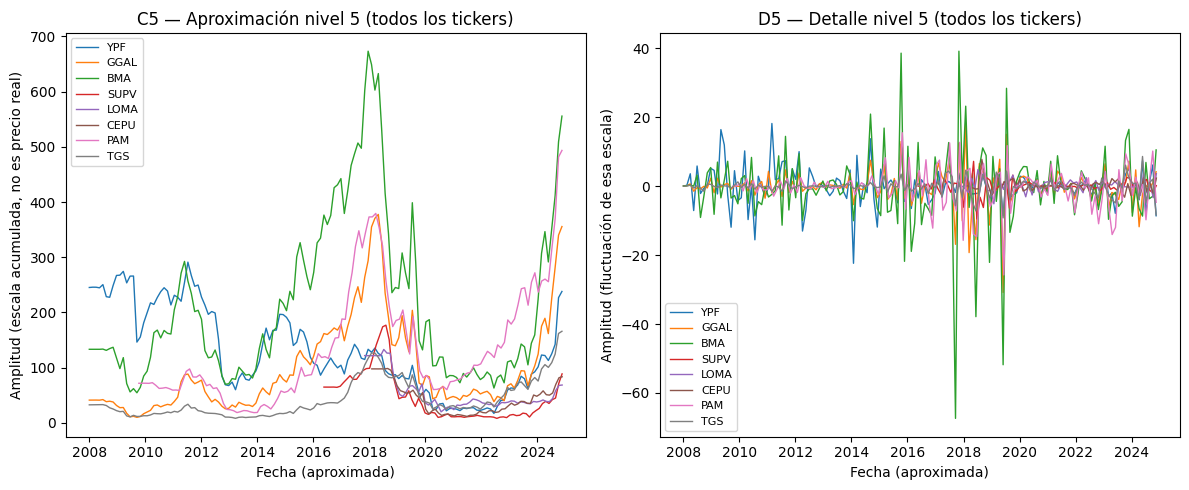

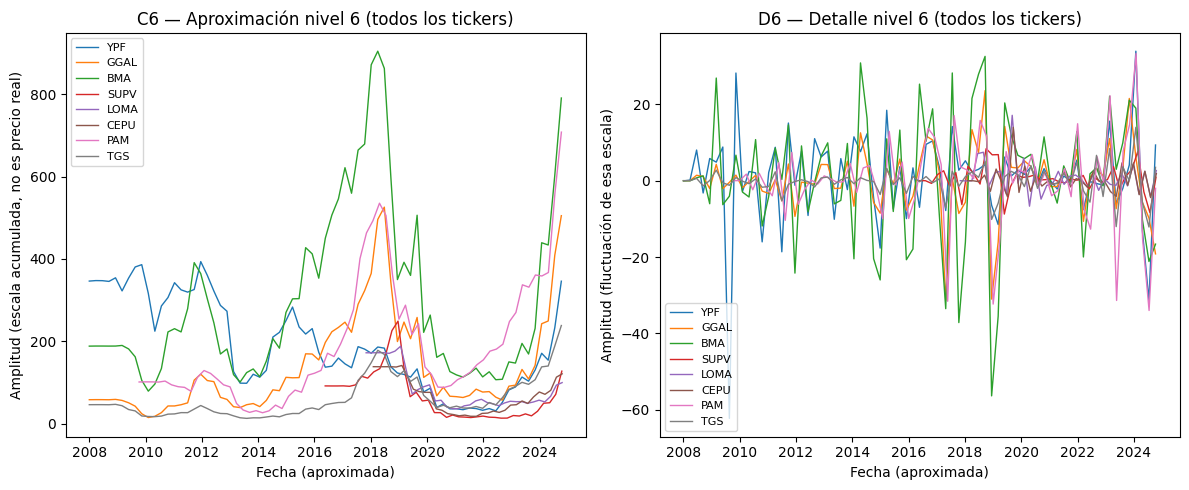

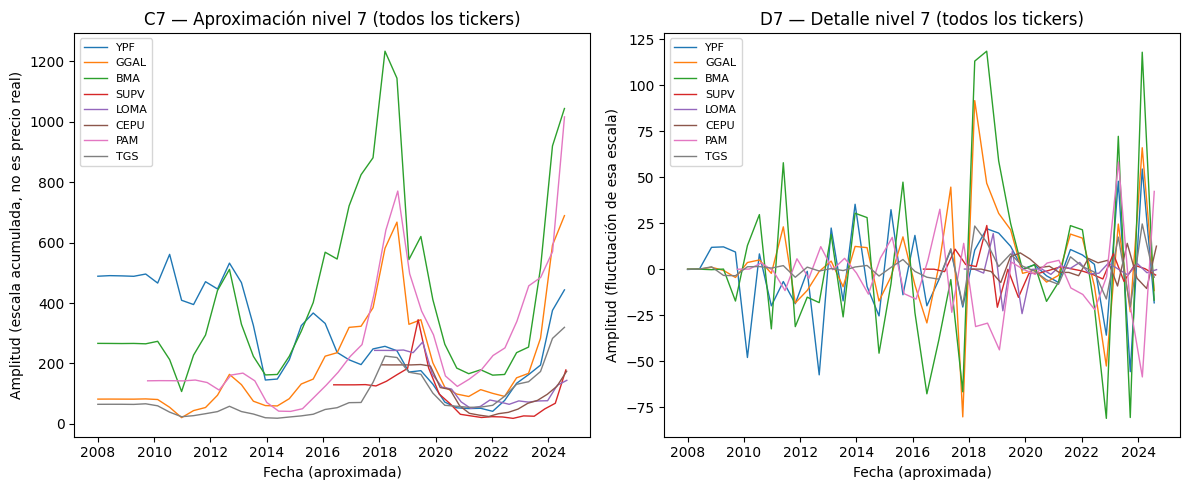

In [140]:
def indices_a_fechas(largo_nivel, fecha_inicio, fecha_fin):
    posiciones_relativas = np.arange(largo_nivel) / largo_nivel
    total_segundos = (fecha_fin - fecha_inicio).total_seconds()
    segundos = posiciones_relativas * total_segundos
    return pd.to_datetime(fecha_inicio) + pd.to_timedelta(segundos, unit='s')


for nivel in range(1, nivel_max + 1):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ticker in tickers:
        fecha_inicio = data[ticker].dropna().index[0]
        fecha_fin = data[ticker].dropna().index[-1]
        nivel_max = resultados_por_nivel_todos[ticker]['nivel_max']
        resultados_por_nivel_ggal = resultados_por_nivel_todos[ticker]['resultados_por_nivel']

        # Si este ticker no llega a tener ese nivel (por tener menos historia), lo saltamos
        if nivel > nivel_max:
            continue

        cA_nivel = resultados_por_nivel_ggal[nivel]['cA']
        cD_nivel = resultados_por_nivel_ggal[nivel]['cD']

        fechas_cA = indices_a_fechas(len(cA_nivel), fecha_inicio, fecha_fin)
        fechas_cD = indices_a_fechas(len(cD_nivel), fecha_inicio, fecha_fin)

        axes[0].plot(fechas_cA, cA_nivel, color=color_map[ticker], label=ticker, linewidth=1)
        axes[1].plot(fechas_cD, cD_nivel, color=color_map[ticker], label=ticker, linewidth=1)

    axes[0].set_title(f'C{nivel} — Aproximación nivel {nivel} (todos los tickers)')
    axes[0].set_xlabel('Fecha (aproximada)')
    axes[0].set_ylabel('Amplitud (escala acumulada, no es precio real)')
    axes[0].legend(fontsize=8)

    axes[1].set_title(f'D{nivel} — Detalle nivel {nivel} (todos los tickers)')
    axes[1].set_xlabel('Fecha (aproximada)')
    axes[1].set_ylabel('Amplitud (fluctuación de esa escala)')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

Viendo la descomposicion que obtenemos observamos que en el ultimo nivel identificamos los puntos de mayor amplitud, siendo estos 3:
- 2017
- Mediados de 2022
- fines de 2021

Gracias a Mallat logramos identificar cuando y en qué banda ocurre un evento en la señal.
Esto es importante para marcar los momentos mas potentes de fluctuacion del mercado

Todavia no encontré para qué usar estos datos la verdad

# Pair Trading

Una estrategia bastante utilizada en el arbitraje es el Pair Trading. Consiste en identificar gaps entre acciones relacionadas para posicionarnos en relacion de compra o venta.

La idea principal es encontrar 1 accion relacionada a un grupo de acciones y esperar el momento adecuado en la que esa acción se aleje de aquellos. Una vez alejado, definir un umbral de compra.
- Si está por debajo de ese umbral -> comprar
- Si está por arriba del promedio grupal -> vender

Existen 2 formas de implementar esta estrategia:
1. (El facil) Umbral fijo: Asignamos un % fijo y nos fijamos dia a dia que pasa con esa acción respecto del promedio de acciones.

2. (El bardero) Z-score: Estandarizamos los datos midiendo cuántas desviaciones estándar nos alejamos de la media móvil, cazando al activo cuando se desboca y operando solo cuando la estadística indica que la exageración se fue de las manos y el precio tiene que volver al promedio.

### Indice promedio 

Generamos primero el índice promedio que tenemos entre todos los tickers. Este va a ser el promedio del cual vamos a comparar cada acción para saber cómo estamos posicionados.

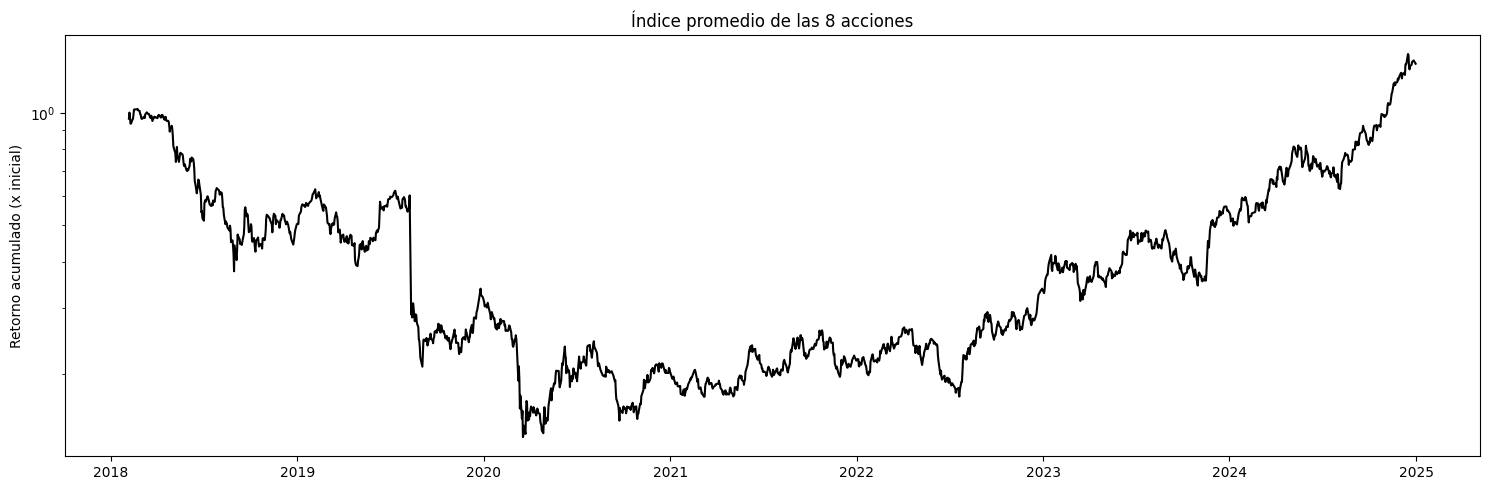

In [161]:
# Índice sintético: retorno acumulado promedio del panel

# pct_change calcula el cambio porcentual entre el actual y el siguiente
# Ejemplo -> data = [90, 91, 85]
# data.pct_change() utiliza el calculo: actual/anterior - 1. 
# # En este caso:
# 1. Nan
# 2. 0.01111 (91/90 - 1)
# 3. -0.0659 (85/91 - 1)
retornos_todos = data[tickers].pct_change().dropna()

# Índice = retorno acumulado promedio de las 8 acciones
retorno_promedio_panel = retornos_todos.mean(axis=1)
indice_panel = (1 + retorno_promedio_panel).cumprod()

plt.figure(figsize=(15, 5))
plt.plot(indice_panel.index, indice_panel, color='black', linewidth=1.5)
plt.title('Índice promedio de las 8 acciones')
plt.ylabel('Retorno acumulado (x inicial)')
plt.yscale('log')
plt.tight_layout()
plt.show()

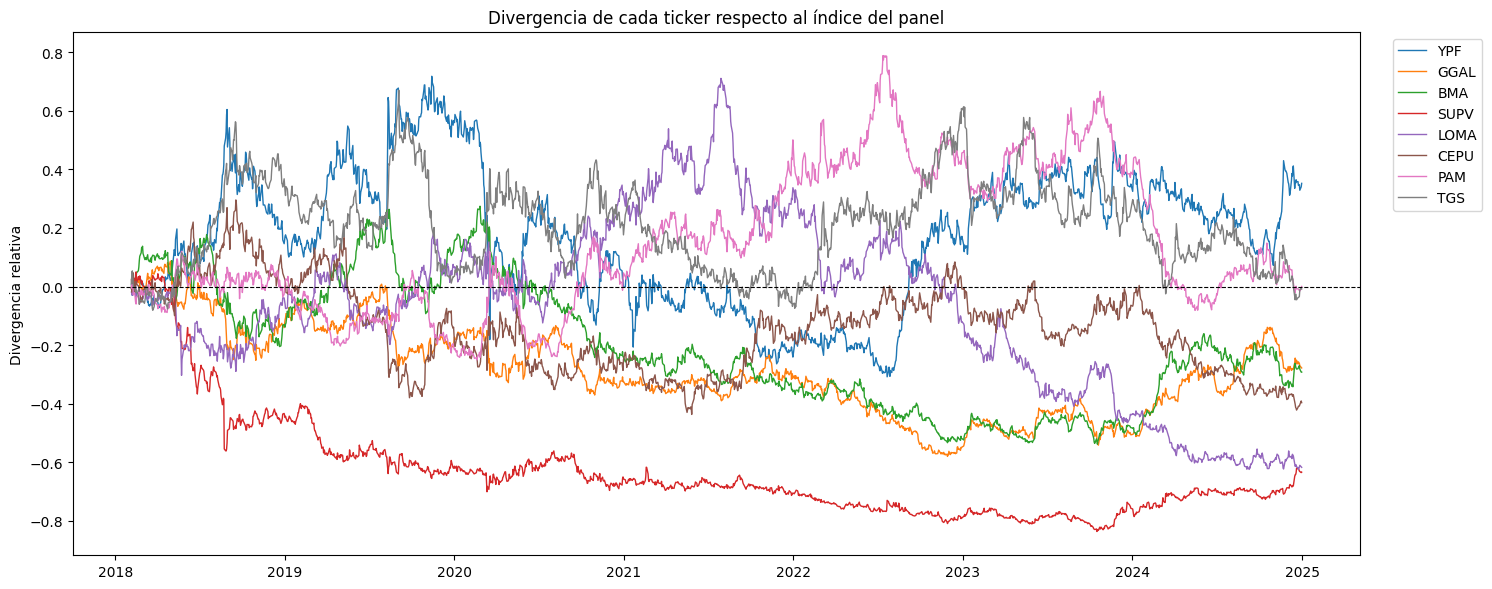

In [142]:
# Divergencia de cada ticker respecto al índice del panel

divergencias = {}

for ticker in tickers:
    retorno_acumulado_ticker = (1 + retornos_todos[ticker]).cumprod()

    # Divergencia relativa: cuánto más/menos ganó el ticker que el panel promedio
    divergencia = retorno_acumulado_ticker / indice_panel - 1
    divergencias[ticker] = divergencia

df_divergencias = pd.DataFrame(divergencias)

fig, ax = plt.subplots(figsize=(15, 6))

# Le metemos un peu de couleur 
for ticker in tickers:
    ax.plot(df_divergencias.index, df_divergencias[ticker], color=color_map[ticker], label=ticker, linewidth=1)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Divergencia de cada ticker respecto al índice del panel')
ax.set_ylabel('Divergencia relativa')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Umbral fijo (3%)

In [150]:
# Función para calcular la estrategia por ticker

def calcular_señal_porcentaje(ticker, df_divergencias, data_precios, umbral_compra=-0.03, umbral_venta=0.0):
    divergencia = df_divergencias[ticker].dropna()
    posicion = pd.Series(0, index=divergencia.index)
    en_posicion = False
    
    for fecha in divergencia.index:
        div_actual = divergencia.loc[fecha]
        
        # Reglas basadas en el porcentaje fijo de divergencia
        if div_actual <= umbral_compra:    
            en_posicion = True
        elif div_actual >= umbral_venta:   
            en_posicion = False

        if en_posicion == True:
            posicion.loc[fecha] = 1
        else:
            posicion.loc[fecha] = 0

    # Detección exacta de cambios de posición (Señales)
    cambio_posicion = posicion.diff()
    es_compra = cambio_posicion == 1
    es_venta = cambio_posicion == -1

    retornos_ticker = data_precios[ticker].pct_change().reindex(posicion.index)
    retorno_estrategia = posicion.shift(1) * retornos_ticker

    return pd.DataFrame({
        'precio': data_precios[ticker],
        'divergencia': divergencia,
        'posicion': posicion,
        'señal_compra': es_compra,
        'señal_venta': es_venta,
        'retorno_bh': retornos_ticker,
        'retorno_estrategia': retorno_estrategia
    }).dropna(subset=['divergencia'])



# Iteración sobre todos los Tickers

resultados_estrategia_pct = {}
lista_bitacoras_pct = []

UMBRAL_COMPRA = -0.03 # -3% respecto al promedio

for ticker in tickers:
    # Calculamos la estrategia
    df_res = calcular_señal_porcentaje(ticker, df_divergencias, data, umbral_compra=UMBRAL_COMPRA)
    resultados_estrategia_pct[ticker] = df_res
    
    # Filtramos los días donde hubo una orden (Compra o Venta)
    df_trades = df_res[df_res['señal_compra'] | df_res['señal_venta']].copy()
    
    if not df_trades.empty:
        df_trades['Acción'] = np.where(df_trades['señal_compra'], 'COMPRA', 'VENTA')
        df_trades['Ticker'] = ticker
        
        # Seleccionamos y ordenamos columnas para la bitácora
        tabla_trade = df_trades[['Ticker', 'Acción', 'precio', 'divergencia']]
        lista_bitacoras_pct.append(tabla_trade)

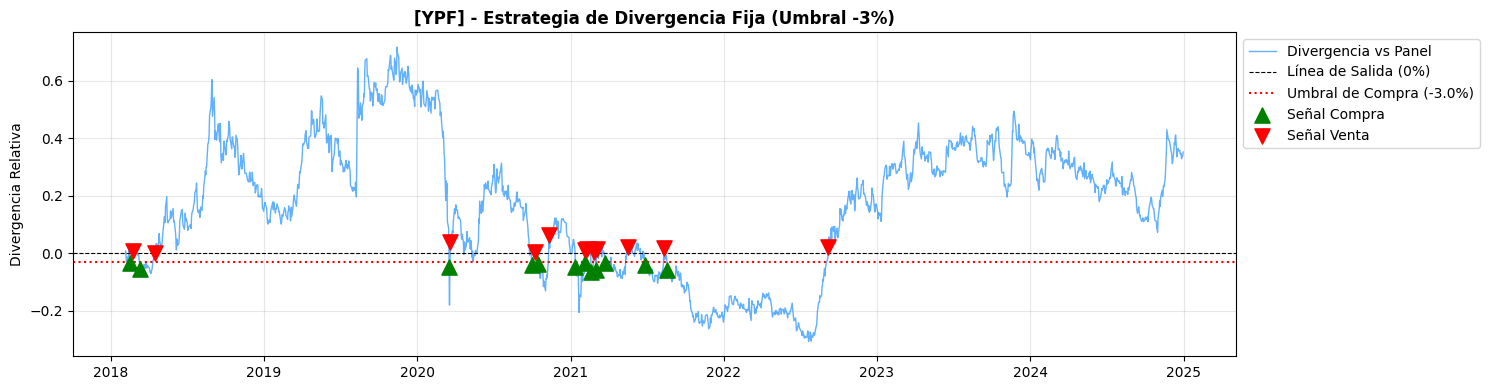

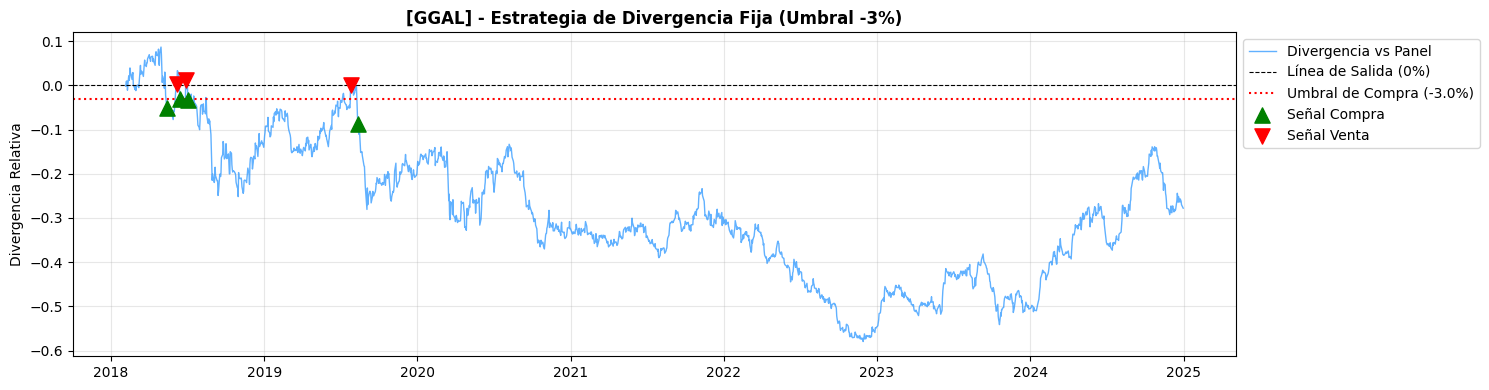

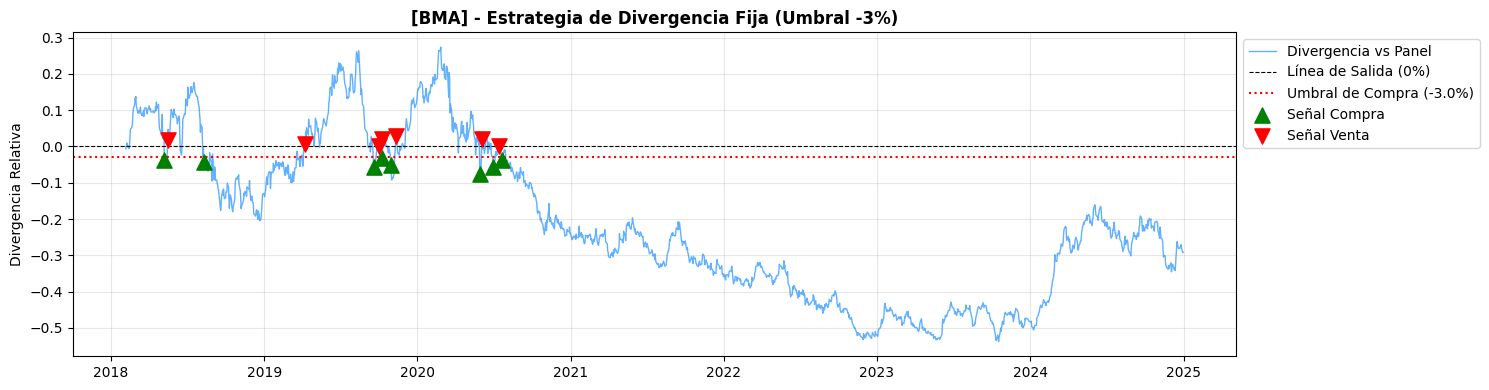

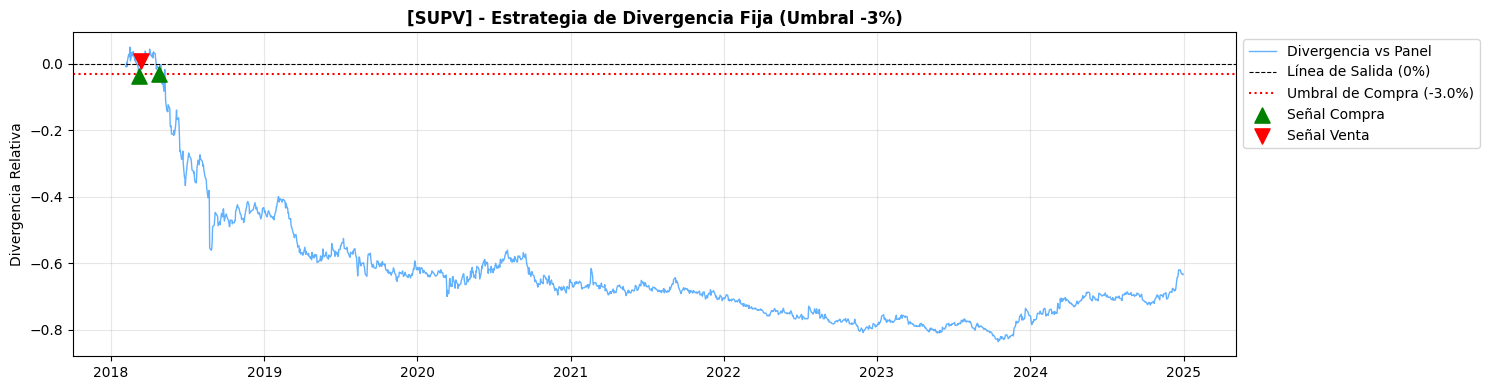

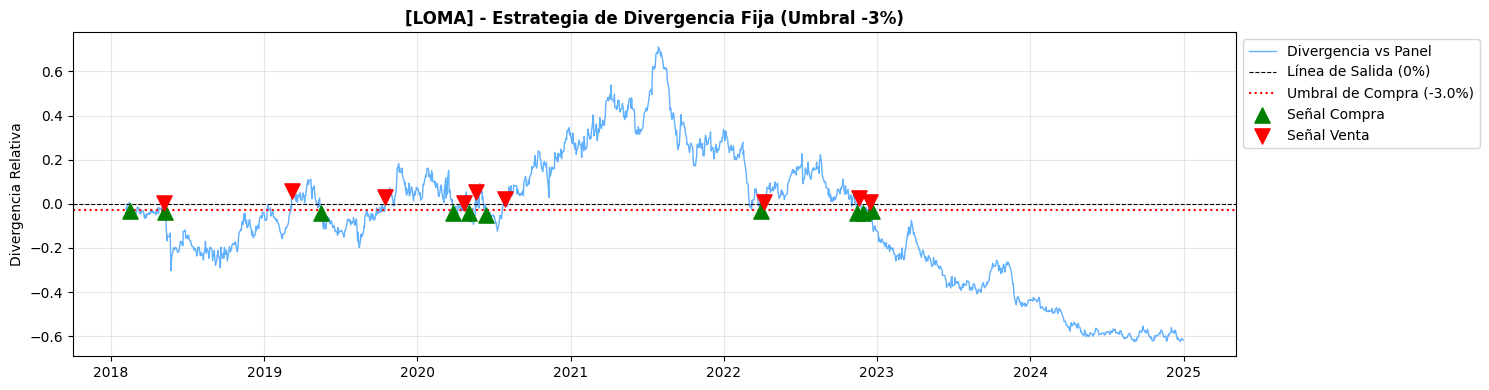

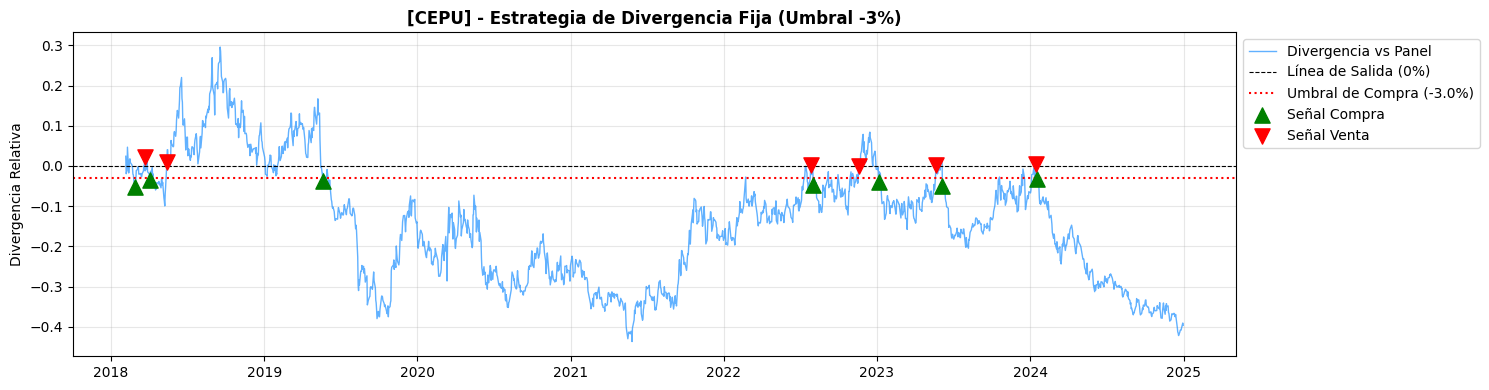

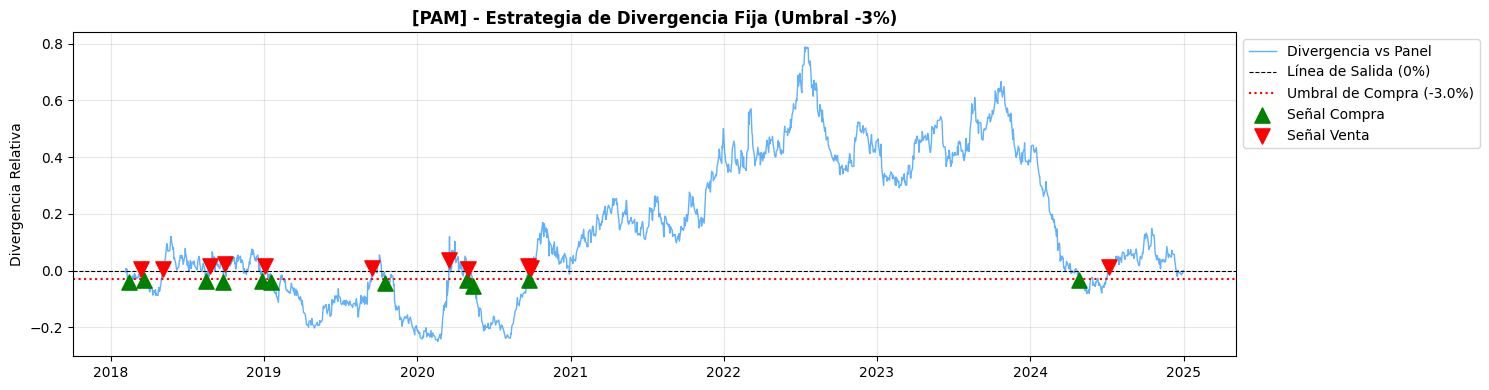

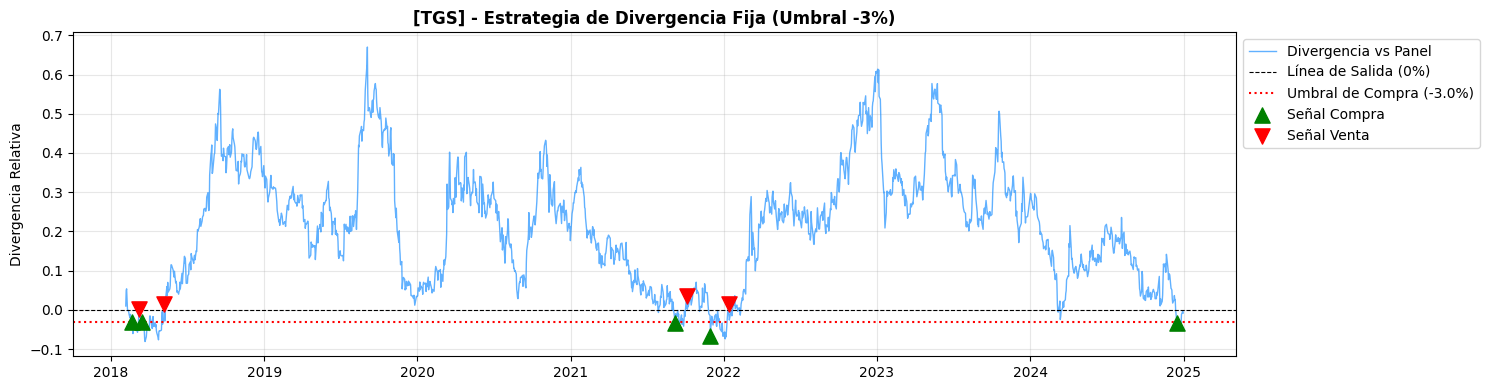

In [151]:
# Visualización de señales para todos los tickers


for ticker in tickers:
    df_res = resultados_estrategia_pct[ticker]
    
    fig, ax = plt.subplots(figsize=(15, 4))
    
    # 1. Ploteamos la divergencia del ticker respecto al panel
    ax.plot(df_res.index, df_res['divergencia'], color='dodgerblue', alpha=0.7, label='Divergencia vs Panel', linewidth=1)
    
    # 2. Líneas de referencia (Umbrales)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, label='Línea de Salida (0%)')
    ax.axhline(y=UMBRAL_COMPRA, color='red', linestyle=':', linewidth=1.5, label=f'Umbral de Compra ({UMBRAL_COMPRA*100}%)')
    
    # 3. Marcadores de Compra (Triángulos Verdes)
    fechas_compra = df_res[df_res['señal_compra']].index
    if not fechas_compra.empty:
        ax.scatter(fechas_compra, df_res.loc[fechas_compra, 'divergencia'], 
                   color='green', marker='^', s=120, label='Señal Compra', zorder=5)
    
    # 4. Marcadores de Venta (Triángulos Rojos)
    fechas_venta = df_res[df_res['señal_venta']].index
    if not fechas_venta.empty:
        ax.scatter(fechas_venta, df_res.loc[fechas_venta, 'divergencia'], 
                   color='red', marker='v', s=120, label='Señal Venta', zorder=5)
    
    # Estética del gráfico
    ax.set_title(f'[{ticker}] - Estrategia de Divergencia Fija (Umbral -3%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Divergencia Relativa')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

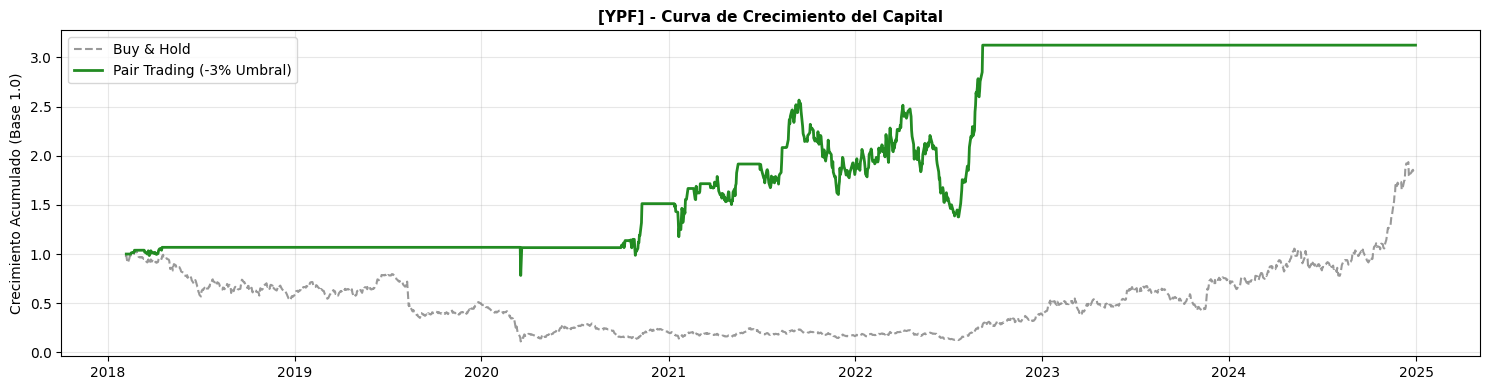

[YPF] 
 Buy & Hold: 1.83x (+83.3%) 
 Pair Trading: 3.12x (+212.5%)
----------------------------------------


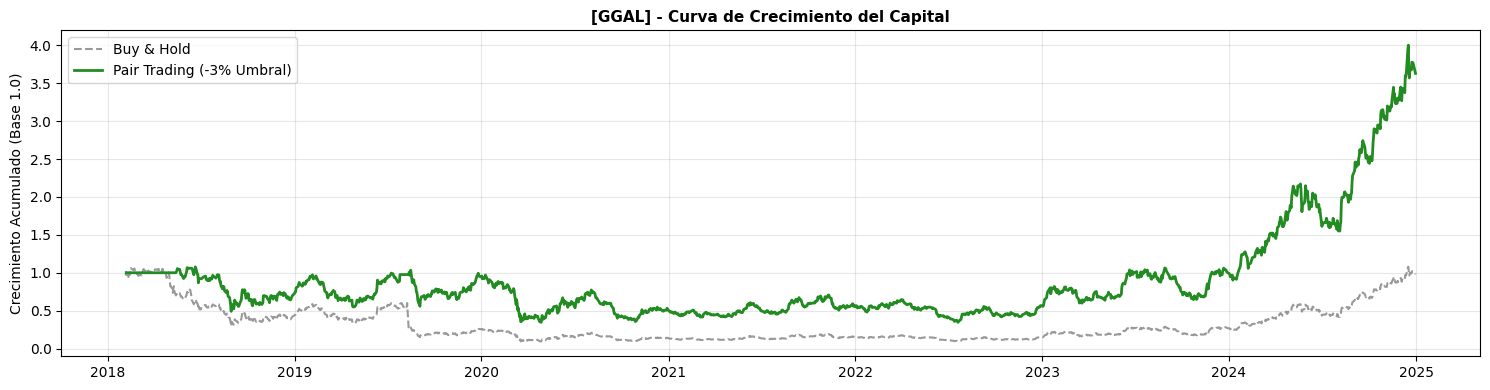

[GGAL] 
 Buy & Hold: 0.98x (-2.1%) 
 Pair Trading: 3.63x (+263.1%)
----------------------------------------


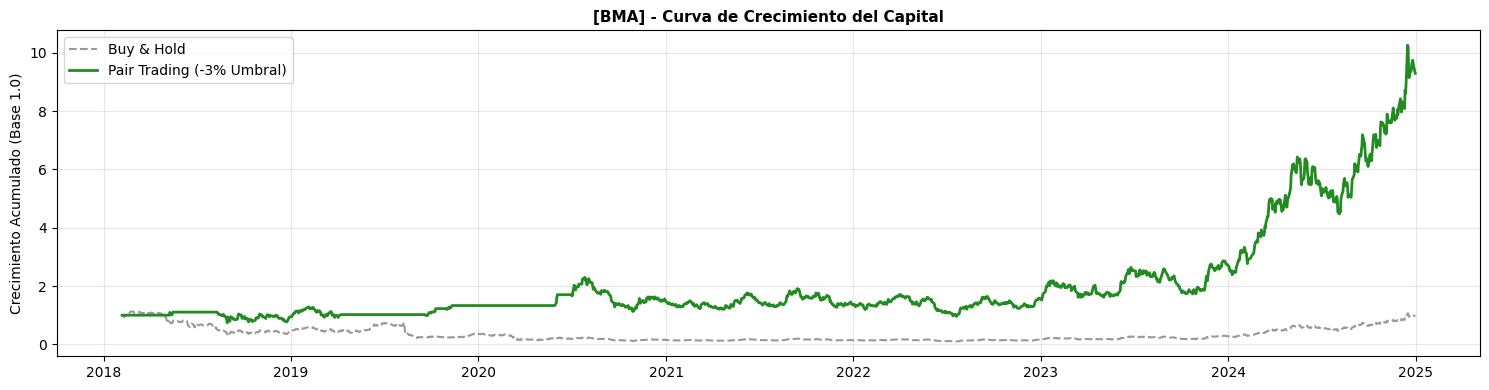

[BMA] 
 Buy & Hold: 0.96x (-4.0%) 
 Pair Trading: 9.29x (+829.2%)
----------------------------------------


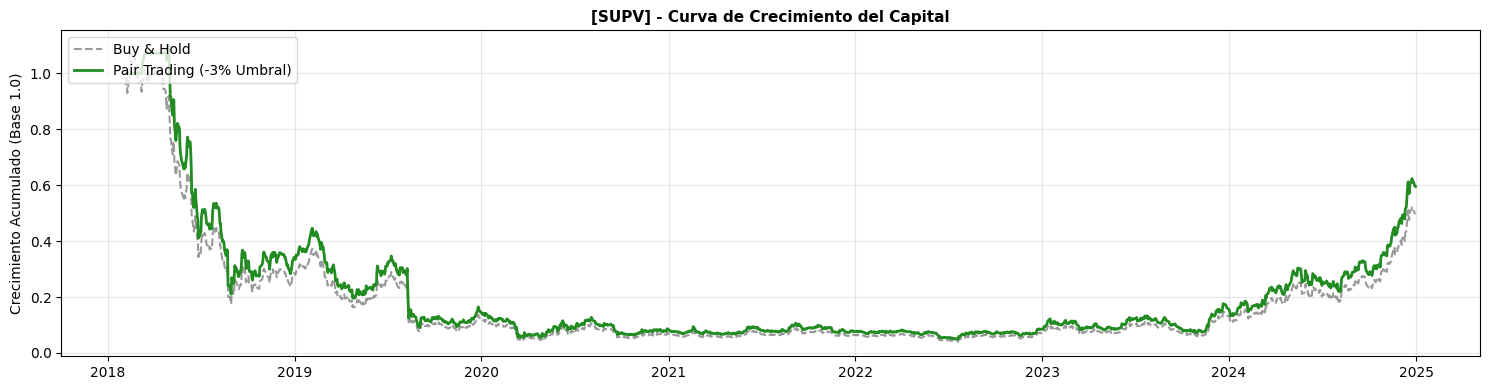

[SUPV] 
 Buy & Hold: 0.50x (-50.3%) 
 Pair Trading: 0.60x (-40.5%)
----------------------------------------


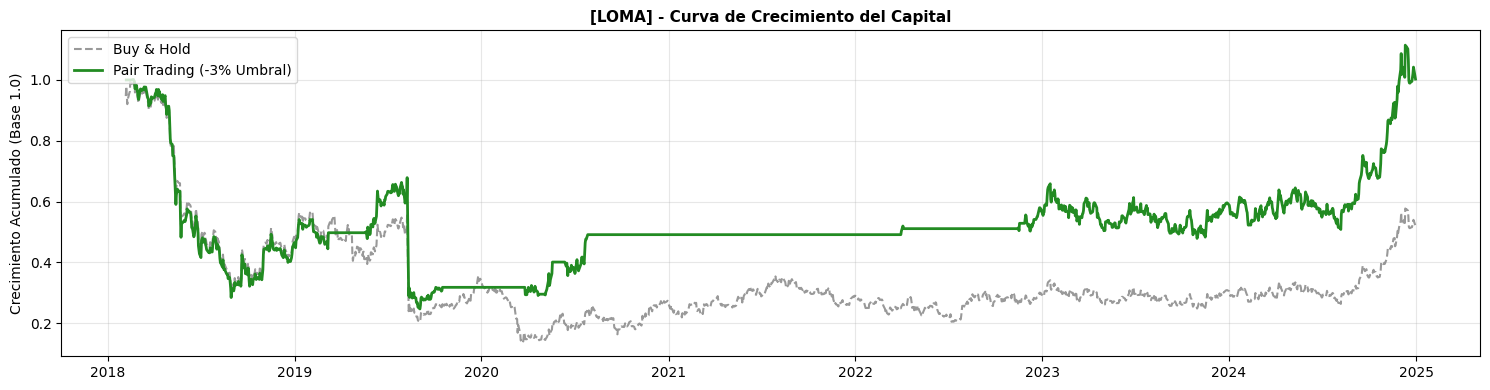

[LOMA] 
 Buy & Hold: 0.52x (-48.1%) 
 Pair Trading: 1.00x (+0.3%)
----------------------------------------


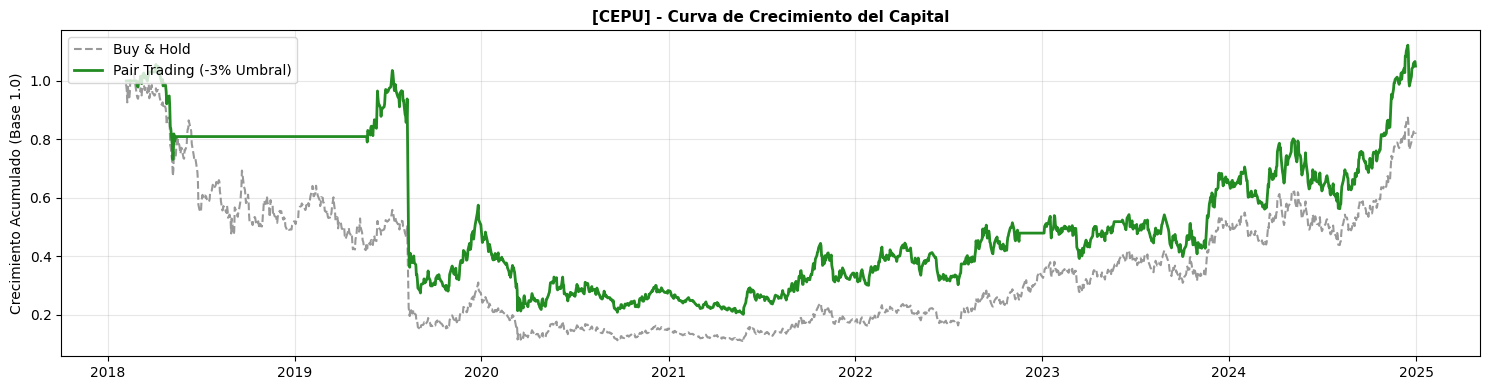

[CEPU] 
 Buy & Hold: 0.82x (-18.1%) 
 Pair Trading: 1.05x (+5.1%)
----------------------------------------


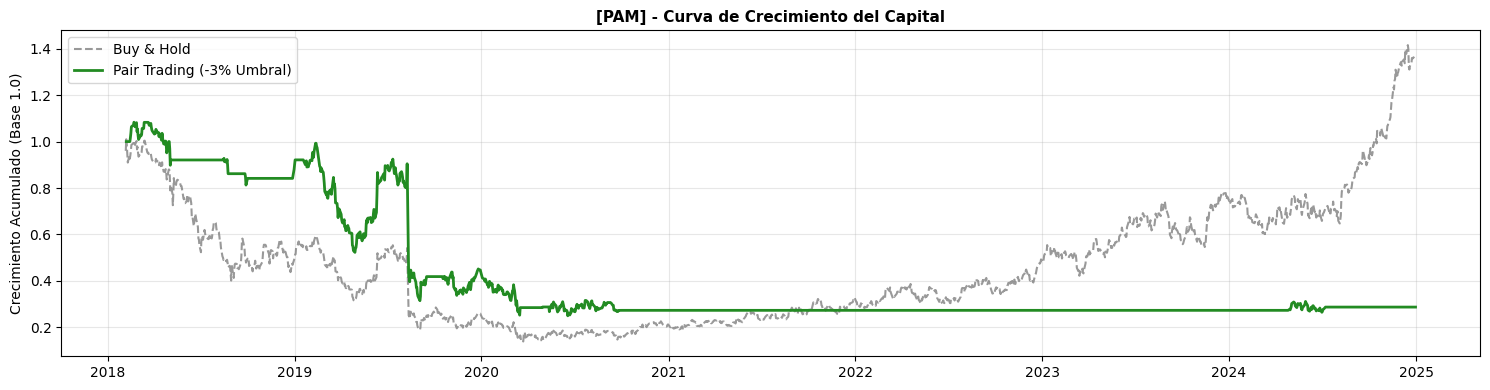

[PAM] 
 Buy & Hold: 1.36x (+35.6%) 
 Pair Trading: 0.29x (-71.3%)
----------------------------------------


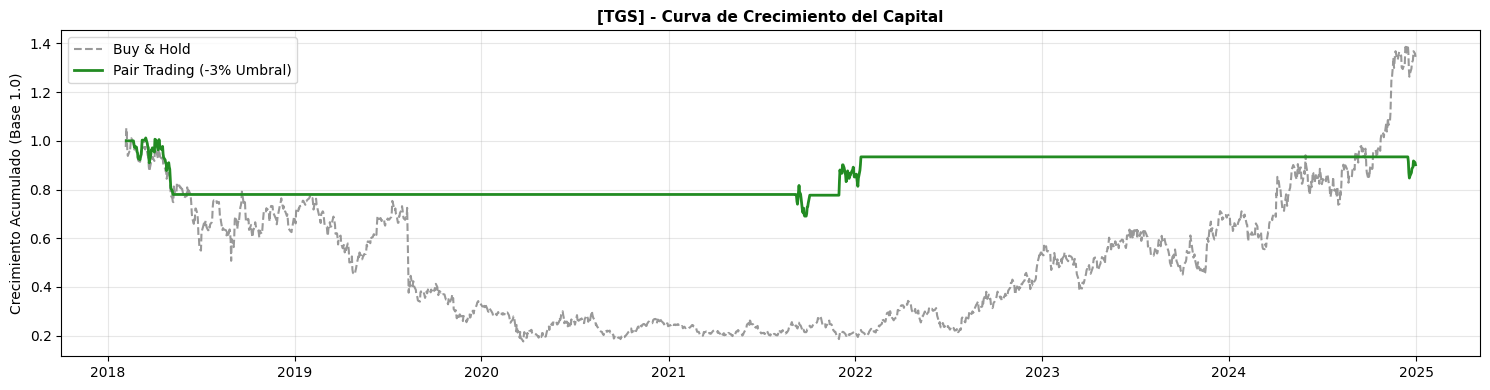

[TGS] 
 Buy & Hold: 1.34x (+34.5%) 
 Pair Trading: 0.90x (-9.8%)
----------------------------------------


In [ ]:
# Gráfico y Print de Rendimiento por Ticker

for ticker in tickers:
    df_res = resultados_estrategia_pct[ticker]
    
    if df_res.empty:
        continue
        
    # Curvas de Retorno Acumulado (Base 1)
    cum_bh = (1 + df_res['retorno_bh']).cumprod()
    cum_strat = (1 + df_res['retorno_estrategia']).cumprod()

    # Retornos Totales y Multiplicadores "x"
    final_bh_x = cum_bh.iloc[-1]
    final_strat_x = cum_strat.iloc[-1]
    
    ret_tot_bh = final_bh_x - 1
    ret_tot_strat = final_strat_x - 1

    # ============================================
    # Gráfico de Rendimiento Comparativo
    # ============================================
    fig, ax = plt.subplots(figsize=(15, 4))
    
    ax.plot(cum_bh.index, cum_bh, label=f'Buy & Hold', color='gray', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.plot(cum_strat.index, cum_strat, label=f'Pair Trading (-3% Umbral)', color='forestgreen', linewidth=2)
    
    ax.set_title(f'[{ticker}] - Curva de Crecimiento del Capital', fontsize=11, fontweight='bold')
    ax.set_ylabel('Crecimiento Acumulado (Base 1.0)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    print(f"[{ticker}] \n Buy & Hold: {final_bh_x:.2f}x ({ret_tot_bh:+.1%}) \n Pair Trading: {final_strat_x:.2f}x ({ret_tot_strat:+.1%})\n" + "-"*40)

### Pair Trading usando z-score 

La lógica que asume el Pair Trading es que los mercados son elásticos. Si algo se estira demasiado, eventualmente volverá a la media. 

Conociendo esto, buscamos generar una señal coherente que nos permita saber si una acción está en zona de compra o venta relacionándola con el promedio de estas 8 acciones.


Para ésto vamos a utilizar lo que se llama un z-score.

¿Que es el z-score?

$$Z = \frac{X - \mu}{\sigma}$$

Donde:
- $X$ (divergencia): Es el dato actual. Cuánto está rindiendo el ticker hoy en comparación con el índice del panel.

- $\mu$ (media_rolling): Es la "normalidad". Se calcula como el promedio de la divergencia en los últimos 60 días (ventana_zscore = 60). Si la acción suele rendir un 2% por debajo del panel históricamente, ese -2% es su nueva normalidad.

- $\sigma$ (std_rolling): Es la desviación estándar de los últimos 60 días. Funciona como la "regla de medir". Si una acción es muy volátil, un desvío del 5% puede ser normal. Si es muy estable, un desvío del 5% es una anomalía gigante. Dividir por la desviación estándar normaliza esto, permitiéndote comparar acciones volátiles con acciones estables bajo la misma óptica.

---

¿Cómo se interpretan los valores del Z-Score?
Al estandarizar los datos, el Z-score arroja valores que generalmente se mueven entre -3 y +3:

- Z = 0: La divergencia actual es exactamente igual a su promedio de los últimos 60 días. La acción se está comportando tal como se espera.

- Z > 0 (Positivo): La acción está rindiendo por encima de su media histórica frente al panel. (Está relativamente "cara").

- Z < 0 (Negativo): La acción está rindiendo por debajo de su media histórica frente al panel. (Está relativamente "barata").

---

En nuestro caso vamos a definir un umbral de -1.5 (umbral_z = -1.5). 
Es decir, queremos comprar la acción cuando Z < -1.5 y venderla cuando se estabilice, osea cuando Z = 0.

Como bonus, vamos a vender siempre que Z > 1.5 (Z > -umbral_z), puesto que suponemos que está sobrevaluada.

In [143]:
# Señal de reversión: z-score rolling de la divergencia

# vamos a hacer un rolling de 60 dias
ventana_zscore = 60


def calcular_señal_reversion(ticker, umbral_z=-1.5):
    divergencia = df_divergencias[ticker].dropna()

    # Mu
    media_rolling = divergencia.rolling(ventana_zscore).mean()

    # sigma
    std_rolling = divergencia.rolling(ventana_zscore).std()

    z_score = (divergencia - media_rolling) / std_rolling

    # Primera posición:
    # Señal: si el ticker está MUY por debajo de su propia divergencia normal -> comprar 
    # si está MUY por encima -> vender / no tener posición 
    posicion = pd.Series(0, index=divergencia.index)
    posicion[z_score < umbral_z] = 1    # señal de comprar
    posicion[z_score > -umbral_z] = 0   # señal de vender

    # Creamos una serie "posicion" llena de 0s 
    posicion = posicion.replace(0, np.nan).ffill().fillna(0)  # mantenemos posición hasta señal contraria
    # Corregimos: si z vuelve a zona neutra, no necesariamente hay que salir. Definimos salida explícita:
    posicion = pd.Series(0, index=divergencia.index)
    en_posicion = False
    for fecha in divergencia.index:
        z = z_score.loc[fecha]
        if pd.isna(z):      # 1ros 59 dias no hay sufi datos para hacer rolling a 60 dias
            posicion.loc[fecha] = 0 # entonces directamente le clavamos un 0 y a otra cosa
            continue

        ############### Revisar si hay que cambiar la flag hoy ##############
        if z < umbral_z:    # Si caemos abajo del umbral -> tenemos que comprar
            en_posicion = True

        elif z > 0:  # vuelve a la media -> tomamos ganancia y salimos
            en_posicion = False

        ############### Anotamos la posición definitiva para hoy ##############
        if en_posicion == True:   # Si mi flag es true, entonces señalo zona de compra
            posicion.loc[fecha] = 1

        else:                      # Si no, sigo esperando el momento 
            posicion.loc[fecha] = 0

    retornos_ticker = data[ticker].pct_change().reindex(posicion.index)
    retorno_estrategia = posicion.shift(1) * retornos_ticker

    return pd.DataFrame({
        'divergencia': divergencia,
        'z_score': z_score,
        'posicion': posicion,
        'retorno_bh': retornos_ticker,
        'retorno_estrategia': retorno_estrategia
    }).dropna()

In [144]:
# Generamos las señales

def calcular_señales_estrategia(ticker, data_precios, df_divergencias, ventana=60, umbral_z=1.5):
    divergencia = df_divergencias[ticker].dropna()

    media_rolling = divergencia.rolling(ventana).mean()
    std_rolling = divergencia.rolling(ventana).std()
    z_score = (divergencia - media_rolling) / std_rolling

    posicion = pd.Series(0, index=divergencia.index)
    en_posicion = False
    
    for fecha in divergencia.index:
        z = z_score.loc[fecha]
        if pd.isna(z):
            posicion.loc[fecha] = 0
            continue
            
        if z < -umbral_z:
            en_posicion = True      
        elif z > 0: 
            en_posicion = False     
            
        posicion.loc[fecha] = 1 if en_posicion else 0

    cambio_posicion = posicion.diff()
    es_compra = cambio_posicion == 1
    es_venta = cambio_posicion == -1

    retornos_ticker = data_precios[ticker].pct_change().reindex(posicion.index)
    retorno_estrategia = posicion.shift(1) * retornos_ticker

    df_resultados = pd.DataFrame({
        'precio': data_precios[ticker],
        'divergencia': divergencia,
        'z_score': z_score,
        'posicion': posicion,
        'señal_compra': es_compra,
        'señal_venta': es_venta,
        'retorno_bh': retornos_ticker,
        'retorno_estrategia': retorno_estrategia
    }).dropna(subset=['z_score'])
    
    return df_resultados

def obtener_tabla_trades(df_resultados, ticker_nombre):
    df_trades = df_resultados[df_resultados['señal_compra'] | df_resultados['señal_venta']].copy()
    df_trades['Acción'] = np.where(df_trades['señal_compra'], 'COMPRA', 'VENTA')
    
    # Agregamos la columna Ticker para identificarlo en la tabla general
    df_trades['Ticker'] = ticker_nombre
    
    tabla_final = df_trades[['Ticker', 'Acción', 'precio', 'z_score']].copy()
    tabla_final.index.name = 'Fecha'
    
    return tabla_final

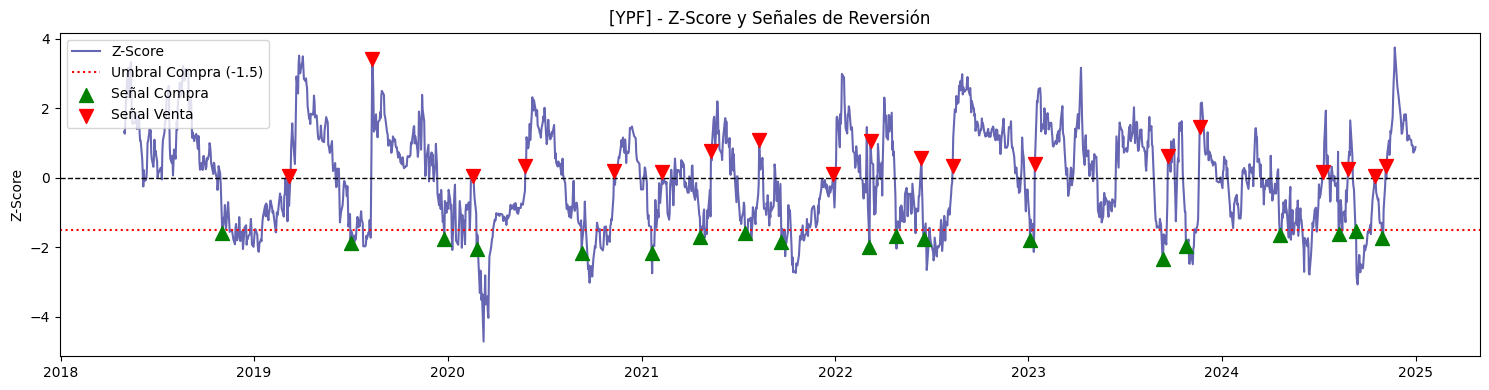

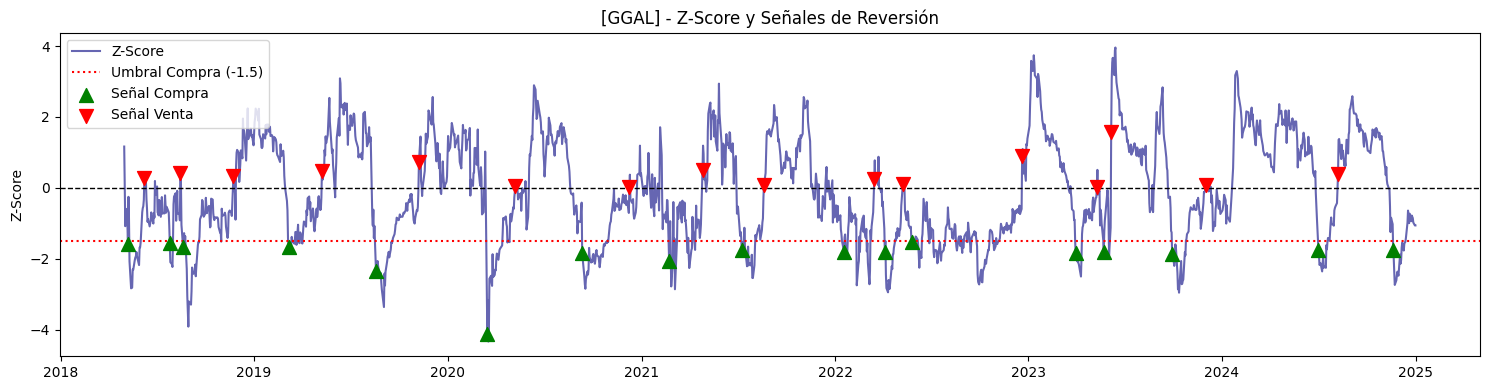

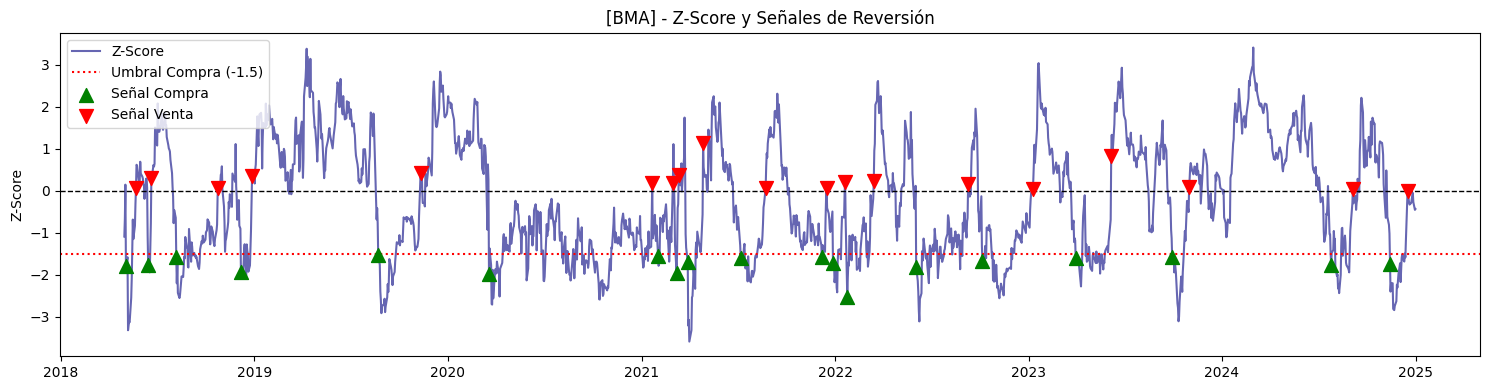

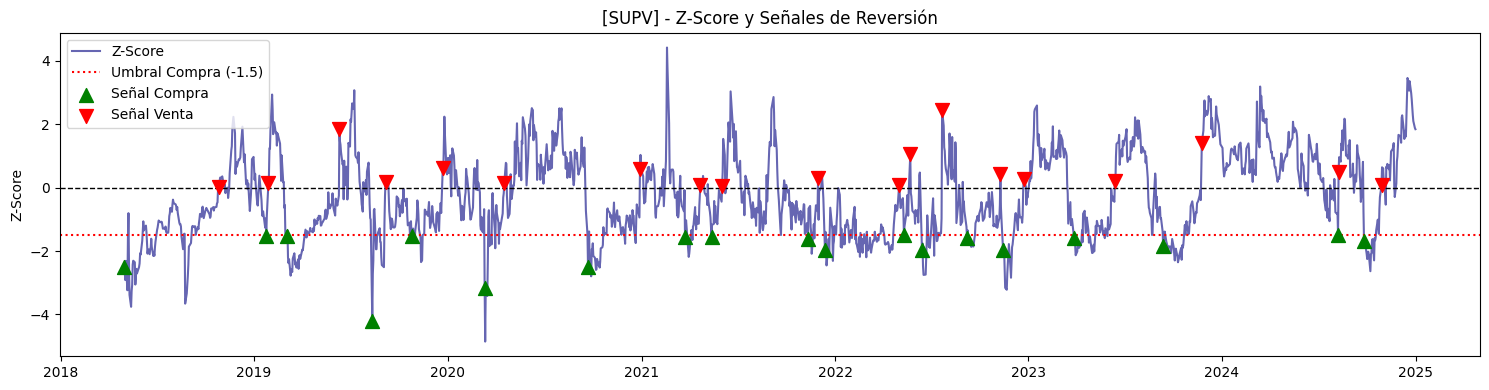

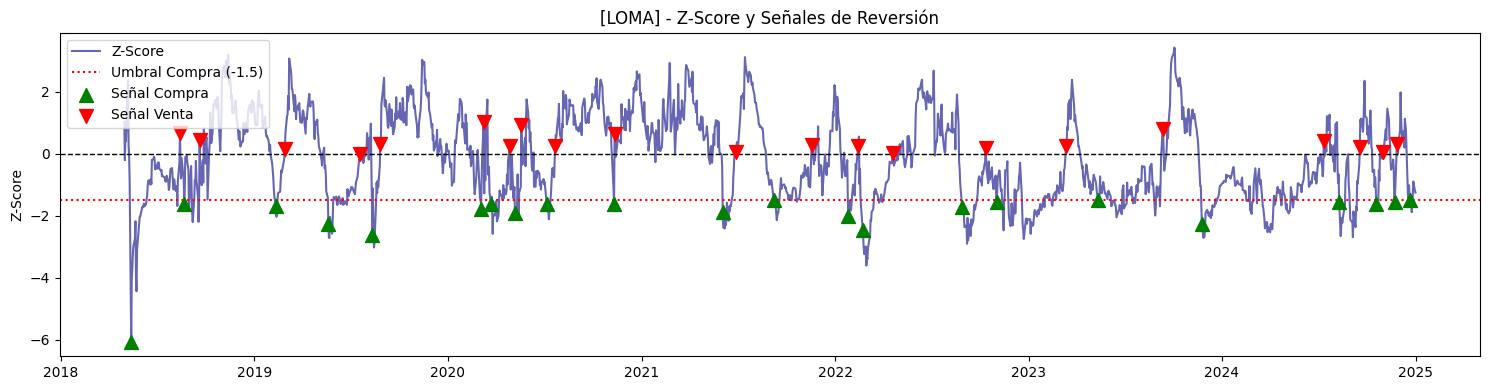

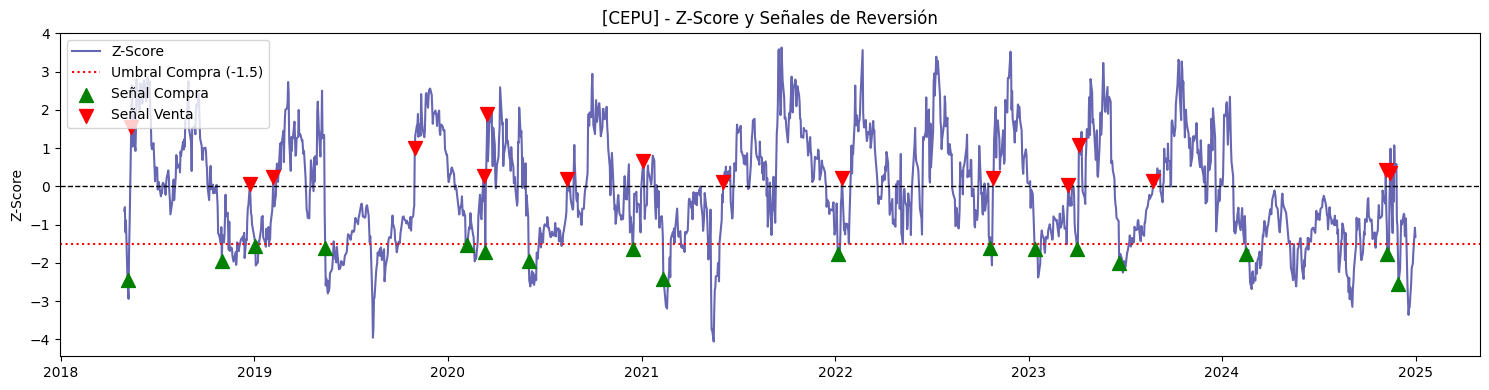

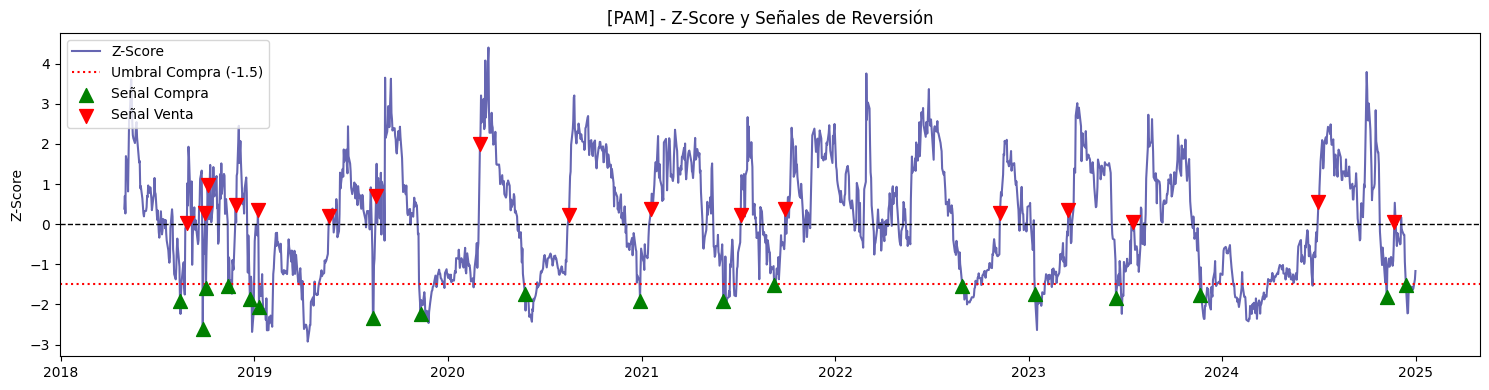

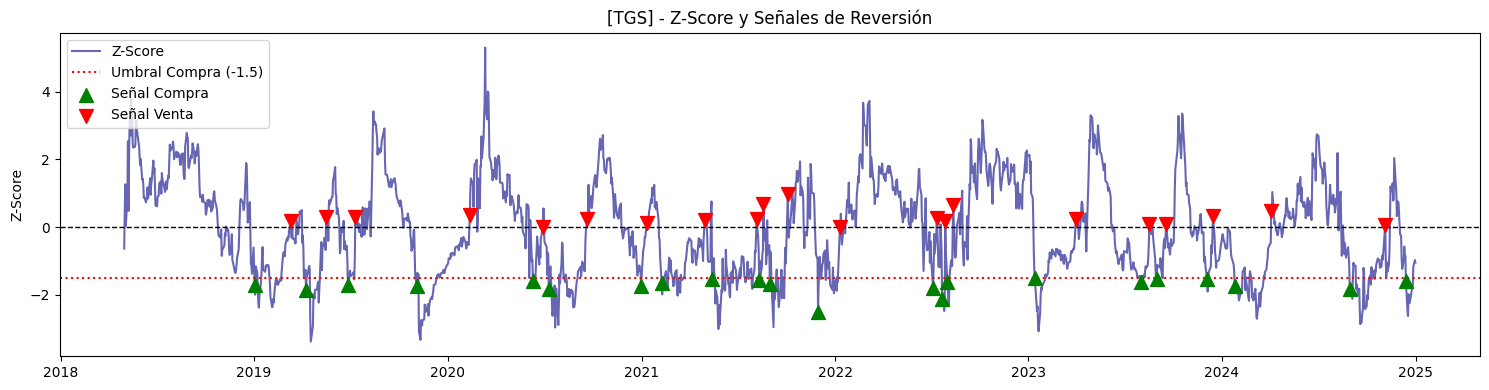

In [145]:
# ============================================
# Ejemplo de Uso y Visualización
# ============================================

resultados_estrategia = {}
lista_bitacoras = []

for ticker in tickers:
    # 1. Calculamos la estrategia para el ticker actual
    df_res = calcular_señales_estrategia(ticker, data, df_divergencias, ventana_zscore, umbral_z)
    resultados_estrategia[ticker] = df_res
    
    # 2. Extraemos los trades y los guardamos en una lista
    bitacora_individual = obtener_tabla_trades(df_res, ticker)
    lista_bitacoras.append(bitacora_individual)

# Iteramos de nuevo para dibujar los gráficos (uno debajo del otro)
for ticker in tickers:
    df_res = resultados_estrategia[ticker]
    
    fig, ax = plt.subplots(figsize=(15, 4))
    
    # Línea base del Z-Score
    ax.plot(df_res.index, df_res['z_score'], color='navy', alpha=0.6, label='Z-Score')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=-umbral_z, color='red', linestyle=':', linewidth=1.5, label=f'Umbral Compra (-{umbral_z})')
    
    # Señales de Compra
    fechas_compra = df_res[df_res['señal_compra']].index
    ax.scatter(fechas_compra, df_res.loc[fechas_compra, 'z_score'], 
               color='green', marker='^', s=100, label='Señal Compra', zorder=5)
    
    # Señales de Venta
    fechas_venta = df_res[df_res['señal_venta']].index
    ax.scatter(fechas_venta, df_res.loc[fechas_venta, 'z_score'], 
               color='red', marker='v', s=100, label='Señal Venta', zorder=5)
    
    ax.set_title(f'[{ticker}] - Z-Score y Señales de Reversión')
    ax.set_ylabel('Z-Score')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

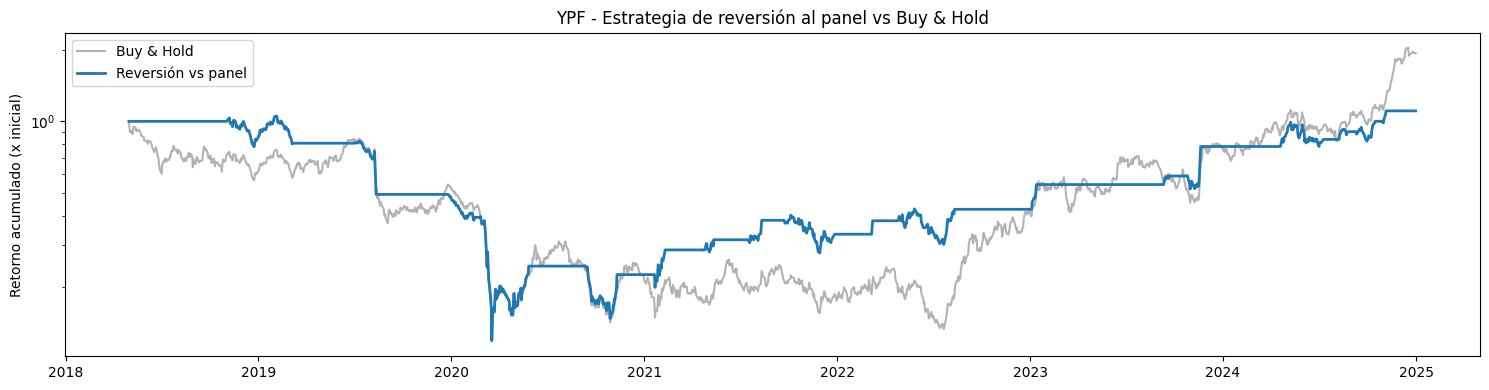

YPF: Buy & Hold 1.94x | Estrategia 1.11x


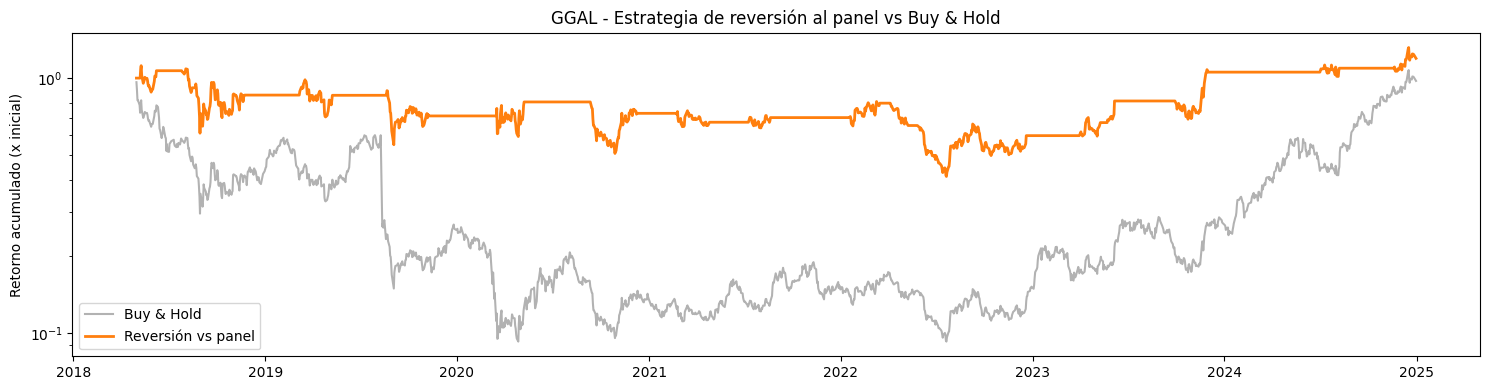

GGAL: Buy & Hold 0.97x | Estrategia 1.19x


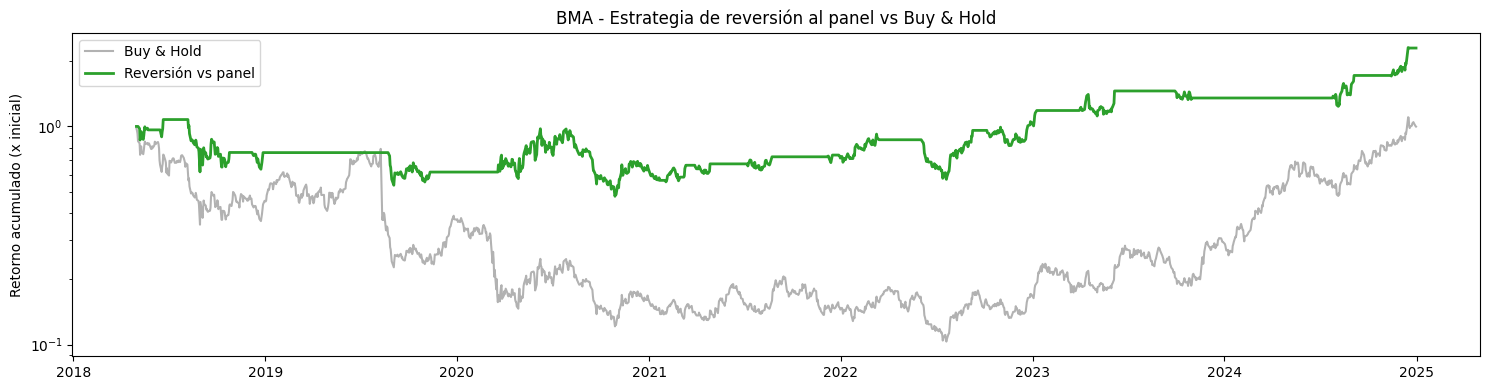

BMA: Buy & Hold 1.00x | Estrategia 2.29x


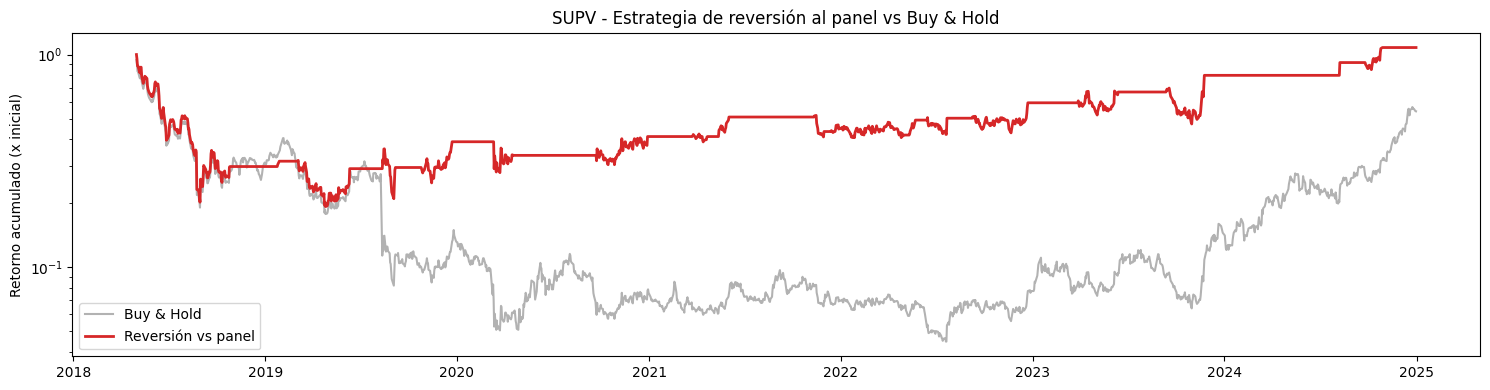

SUPV: Buy & Hold 0.54x | Estrategia 1.08x


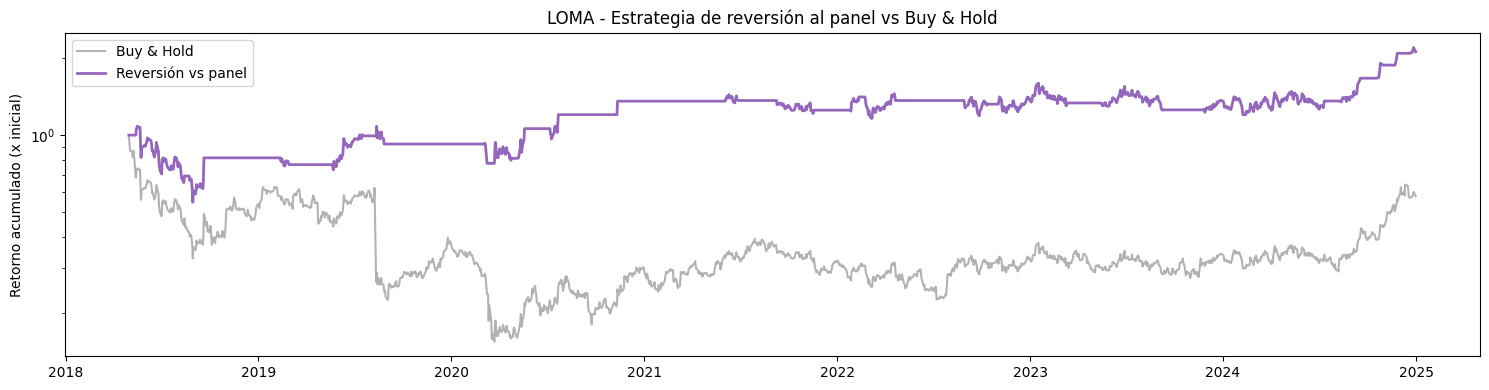

LOMA: Buy & Hold 0.58x | Estrategia 2.12x


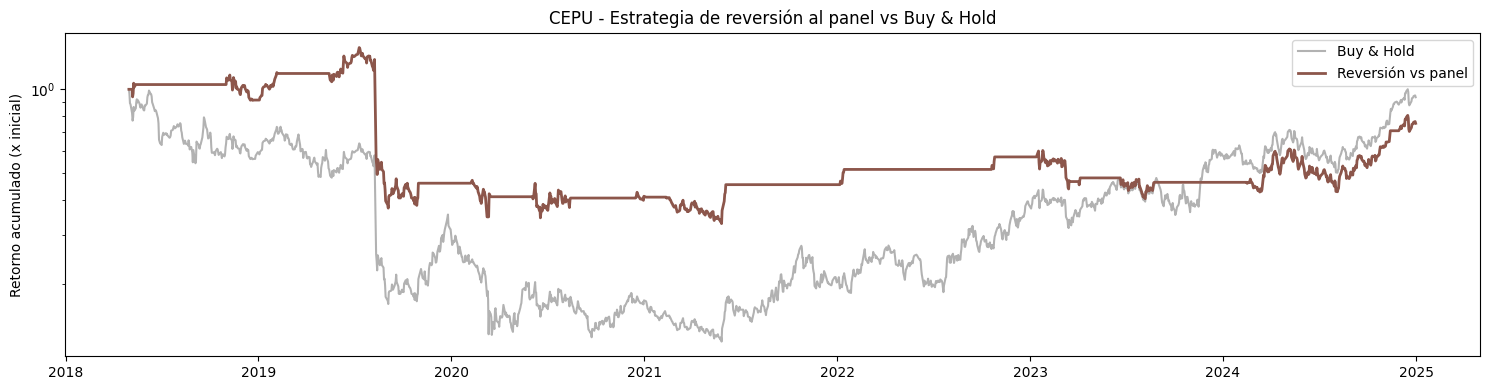

CEPU: Buy & Hold 0.94x | Estrategia 0.75x


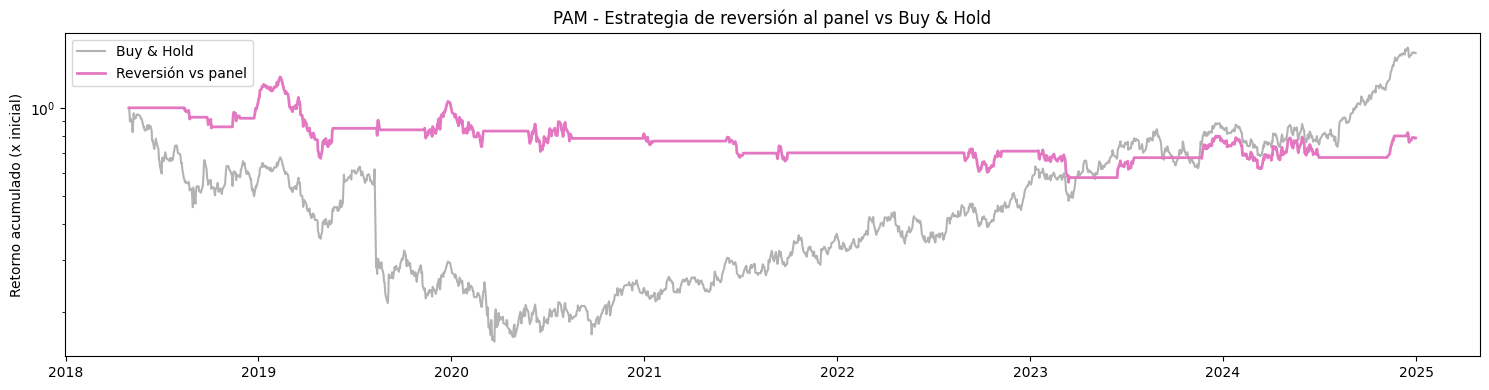

PAM: Buy & Hold 1.54x | Estrategia 0.79x


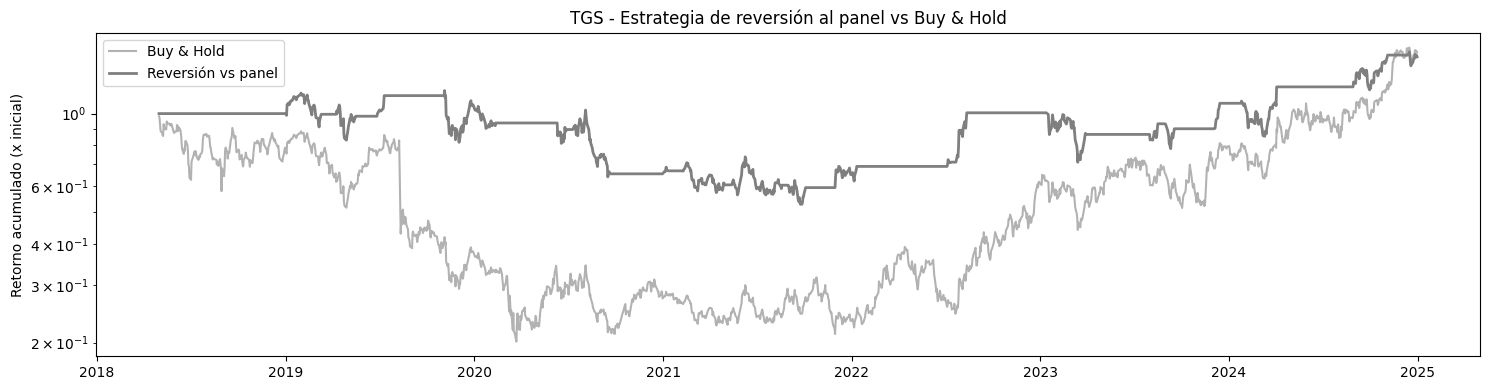

TGS: Buy & Hold 1.54x | Estrategia 1.49x


In [146]:
resultados_reversion = {}

for ticker in tickers:
    resultado = calcular_señal_reversion(ticker)
    resultados_reversion[ticker] = resultado

    acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
    acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

    plt.figure(figsize=(15, 4))
    plt.plot(resultado.index, acumulado_bh, label='Buy & Hold', color='gray', alpha=0.6)
    plt.plot(resultado.index, acumulado_estrategia, label='Reversión vs panel', color=color_map[ticker], linewidth=2)
    plt.title(f'{ticker} - Estrategia de reversión al panel vs Buy & Hold')
    plt.ylabel('Retorno acumulado (x inicial)')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'{ticker}: Buy & Hold {acumulado_bh.iloc[-1]:.2f}x | Estrategia {acumulado_estrategia.iloc[-1]:.2f}x')